# Preprocess Data

This notebook performs the complete preprocessing pipeline required to transform the continuous OPM-MEG recordings into tensors that can later be represented using Matrix Product States (MPS). The preprocessing removes unwanted noise, identifies the timing of each experimental stimulus, extracts individual brain responses (epochs), and stores the processed data in a structured tensor format suitable for tensor decomposition.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mne

## Auditory Task

### 1. Load Data

The loader extracts
- signals – the continuous OPM-MEG recordings
- aux – the auxiliary (trigger) channel
- fs – sampling frequency
- channel_names
- positions
- orientations

In [2]:
from pathlib import Path

LOADED_ROOT = Path("../data/loaded")
SAVE_ROOT = Path("../data/preprocessed")

files = sorted(LOADED_ROOT.rglob("*.npz"))

print(f"Found {len(files)} files")

Found 32 files


In [3]:
for file in files:

    subject = file.parent.parent.name
    task = file.parent.name
    run = file.stem

    print(subject, task, run)

002 auditory run01
002 auditory run02
002 motor run01
002 motor run02
002 motor run03
002 rest run01
002 somatosensory run01
002 somatosensory run02
005 auditory run01
005 auditory run02
005 motor run01
005 motor run02
005 motor run03
005 rest run01
005 somatosensory run01
005 somatosensory run02
006 auditory run01
006 auditory run02
006 motor run01
006 motor run02
006 motor run03
006 rest run01
006 somatosensory run01
006 somatosensory run02
093 auditory run01
093 auditory run02
093 motor run01
093 motor run02
093 motor run03
093 rest run01
093 somatosensory run01
093 somatosensory run02


In [4]:
for file in files:
    data = np.load(file, allow_pickle=True)

    signals = data["signals"]
    aux = data["aux"]
    fs = int(data["fs"])
    channel_names = data["channel_names"].tolist()
    positions = data["positions"]
    orientations = data["orientations"]

    print(file.relative_to(LOADED_ROOT))
    print(signals.shape)
    print(aux.shape)
    print(fs)

002/auditory/run01.npz
(30, 856000)
(1, 856000)
2000
002/auditory/run02.npz
(30, 864000)
(1, 864000)
2000
002/motor/run01.npz
(30, 682000)
(3, 682000)
2000
002/motor/run02.npz
(30, 632000)
(3, 632000)
2000
002/motor/run03.npz
(30, 628000)
(3, 628000)
2000
002/rest/run01.npz
(30, 648000)
(1, 648000)
2000
002/somatosensory/run01.npz
(30, 624000)
(1, 624000)
2000
002/somatosensory/run02.npz
(30, 622000)
(1, 622000)
2000
005/auditory/run01.npz
(30, 856000)
(1, 856000)
2000
005/auditory/run02.npz
(30, 868000)
(1, 868000)
2000
005/motor/run01.npz
(30, 610000)
(3, 610000)
2000
005/motor/run02.npz
(30, 614000)
(3, 614000)
2000
005/motor/run03.npz
(30, 612000)
(3, 612000)
2000
005/rest/run01.npz
(30, 614000)
(1, 614000)
2000
005/somatosensory/run01.npz
(30, 624000)
(1, 624000)
2000
005/somatosensory/run02.npz
(30, 620000)
(1, 620000)
2000
006/auditory/run01.npz
(30, 842000)
(1, 842000)
2000
006/auditory/run02.npz
(30, 856000)
(1, 856000)
2000
006/motor/run01.npz
(30, 640000)
(3, 640000)
2000
00

002/auditory/run01.npz (30, 856000) (1, 856000) 2000
│                       │            │           │
│                       │            │           └── Sampling frequency (Hz)
│                       │            └────────────── Auxiliary channels (auditory and somatosensory: this channel contains the stimulus trigger pulse, motor: three auxiliary channels, synchronization pulses, eye movement recordings (EOG), electromyography (EMG))
│                       └─────────────────────────── Channels (15 physical OPM sensors & 2 measurement axes (Y and Z)) , time samples
└────────────────────────────────────────────────── Subject / Task / Run

30 MEG channels, 1 trigger channel, 856000 time samples, sampled at 2000 Hz.

### 2. Create MNE

First, create_info() creates metadata describing the recording, including
- channel names,
- sampling frequency,
- sensor type (magnetometers).

The RawArray() object then combines the signal matrix with this metadata.

Using MNE is advantageous because it provides well-tested implementations of common MEG preprocessing methods such as filtering, epoching, spectral analysis, and artifact rejection. Rather than implementing these algorithms manually, the project uses MNE to perform standard preprocessing while keeping the analysis entirely in sensor space.

The resulting raw object now represents the complete continuous MEG recording together with its acquisition information.

In [5]:
for file in files:
    data = np.load(file, allow_pickle=True)

    signals = data["signals"]
    aux = data["aux"]
    fs = int(data["fs"])
    channel_names = data["channel_names"].tolist()
    positions = data["positions"]
    orientations = data["orientations"]

    info = mne.create_info(
        ch_names=channel_names,
        sfreq=fs,
        ch_types=["mag"] * 30
    )

    raw = mne.io.RawArray(
        signals,
        info
    )

    print(raw)

Creating RawArray with float64 data, n_channels=30, n_times=856000
    Range : 0 ... 855999 =      0.000 ...   428.000 secs
Ready.
<RawArray | 30 x 856000 (428.0 s), ~195.9 MiB, data loaded>
Creating RawArray with float64 data, n_channels=30, n_times=864000
    Range : 0 ... 863999 =      0.000 ...   432.000 secs
Ready.
<RawArray | 30 x 864000 (432.0 s), ~197.8 MiB, data loaded>
Creating RawArray with float64 data, n_channels=30, n_times=682000
    Range : 0 ... 681999 =      0.000 ...   341.000 secs
Ready.
<RawArray | 30 x 682000 (341.0 s), ~156.1 MiB, data loaded>
Creating RawArray with float64 data, n_channels=30, n_times=632000
    Range : 0 ... 631999 =      0.000 ...   316.000 secs
Ready.
<RawArray | 30 x 632000 (316.0 s), ~144.7 MiB, data loaded>
Creating RawArray with float64 data, n_channels=30, n_times=628000
    Range : 0 ... 627999 =      0.000 ...   314.000 secs
Ready.
<RawArray | 30 x 628000 (314.0 s), ~143.8 MiB, data loaded>
Creating RawArray with float64 data, n_channe

### 3. Filtering: improves signal-to-noise ratio in sensor space.
   
Removes:
   - Very slow drift (<1 Hz)
   - High-frequency noise (>40 Hz)
   - Power line noise (60 Hz in Japan)
   - Its harmonic (120 Hz)

Raw MEG recordings contain neural activity together with several unwanted signal components.
Filtering improves the signal-to-noise ratio before extracting individual trials.

The PSD estimates how signal power is distributed across frequencies.

This provides a baseline for evaluating whether filtering successfully removes unwanted frequencies.

Typical observations include:
large low-frequency drift,
power-line interference,
physiological rhythms,
high-frequency sensor noise.

In [6]:
for file in files:
    data = np.load(file, allow_pickle=True)

    signals = data["signals"]
    aux = data["aux"]
    fs = int(data["fs"])
    channel_names = data["channel_names"].tolist()
    positions = data["positions"]
    orientations = data["orientations"]

    raw.compute_psd(fmax=120) # Power Spectral Density (PSD)

Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective wind

In [7]:
for file in files:

    data = np.load(file, allow_pickle=True)

    signals = data["signals"]
    aux = data["aux"]
    fs = int(data["fs"])
    channel_names = data["channel_names"].tolist()
    positions = data["positions"]
    orientations = data["orientations"]

    raw_filt = raw.copy()

    raw_filt.filter(
        l_freq=1.0,
        h_freq=40.0
    )

    raw_filt.notch_filter(
        freqs=[60, 120]
    )

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 6601 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 s)

Filtering raw data i

In [8]:
for file in files:

    data = np.load(file, allow_pickle=True)

    signals = data["signals"]
    aux = data["aux"]
    fs = int(data["fs"])
    channel_names = data["channel_names"].tolist()
    positions = data["positions"]
    orientations = data["orientations"]

    raw_filt.compute_psd(fmax=120)

Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


KeyboardInterrupt: 

Comparing the PSD before and after filtering verifies that
low-frequency drift has disappeared,
power-line peaks have been removed,
useful neural frequencies remain largely unchanged.

### 4. Event Detection: cut the continuous data into trials

Trial for motor task with 3 channels

In [13]:
path = Path("../data/loaded/002/motor/run01.npz")

data = np.load(path, allow_pickle=True)

print(path)
print(data.files)

signals = data["signals"]
aux = data["aux"]

print(signals.shape)
print(aux.shape)

../data/loaded/002/motor/run01.npz
['signals', 'aux', 'fs', 'channel_names', 'positions', 'orientations']
(30, 682000)
(3, 682000)


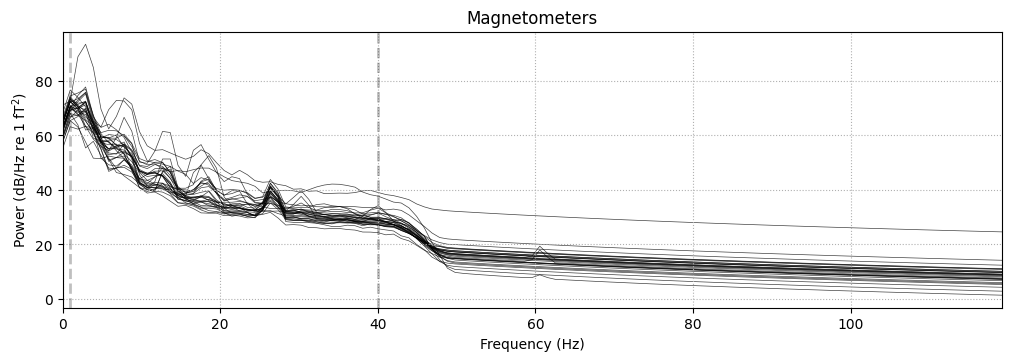

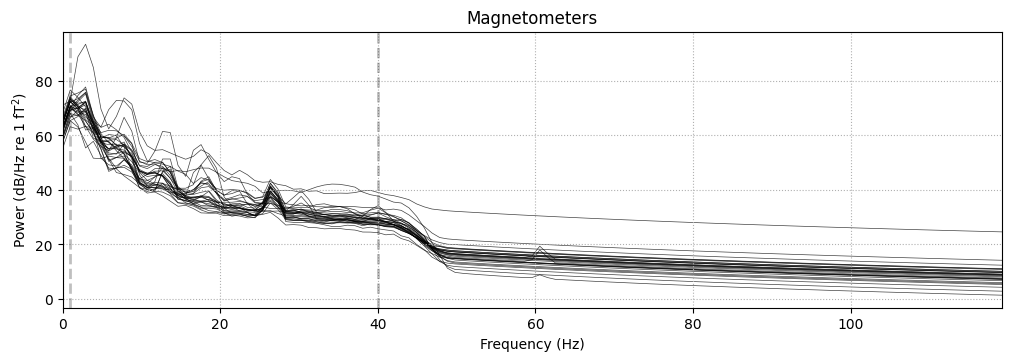

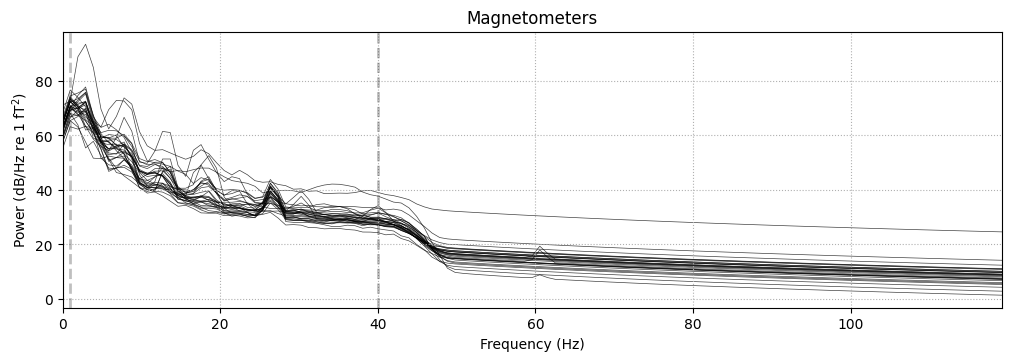

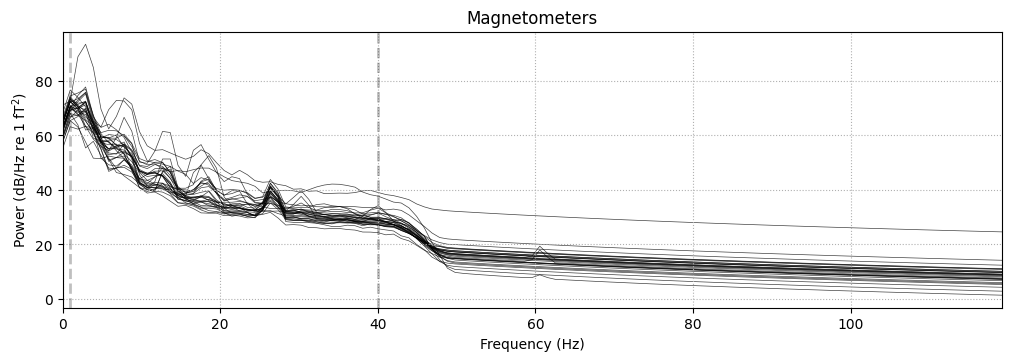

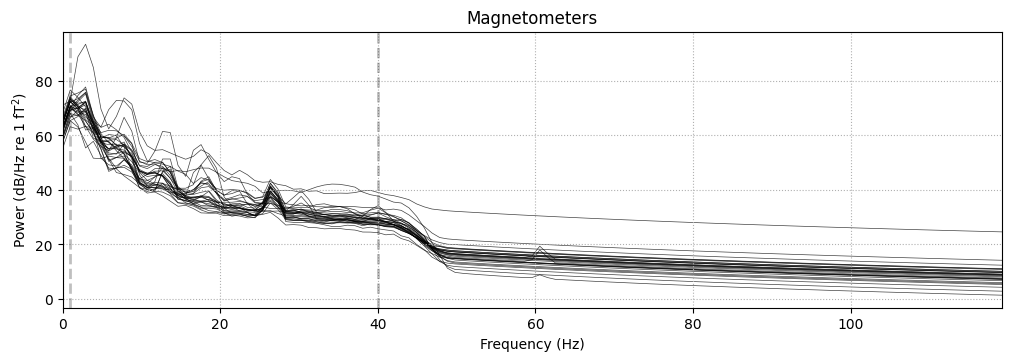

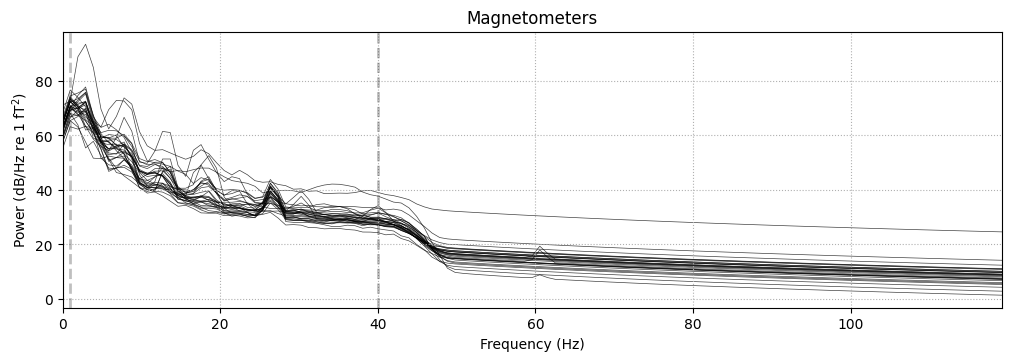

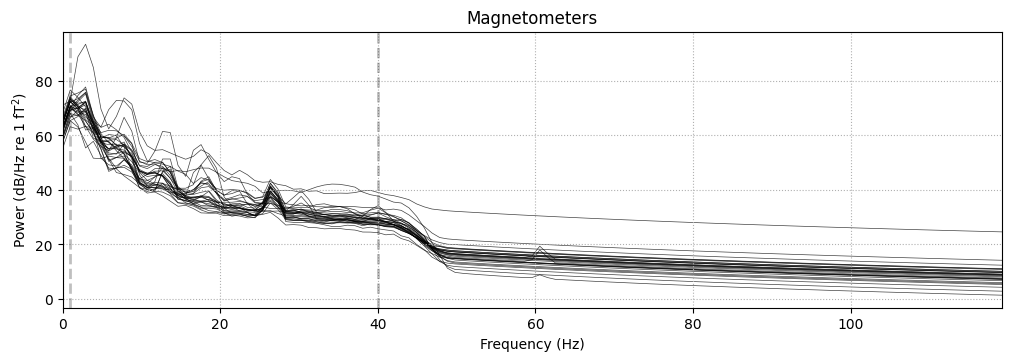

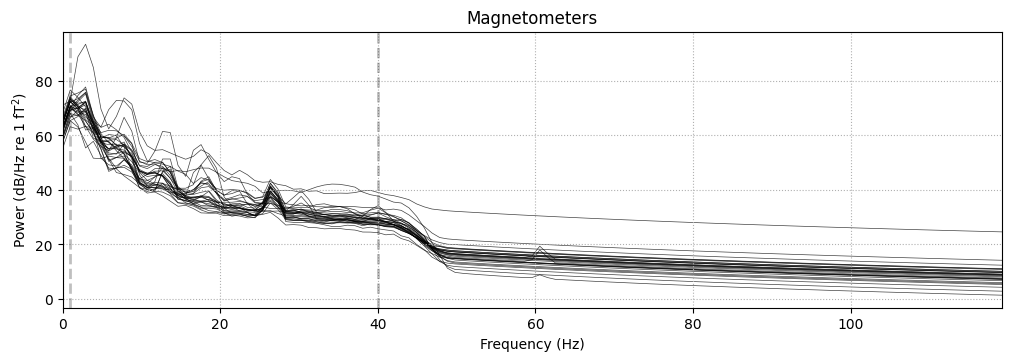

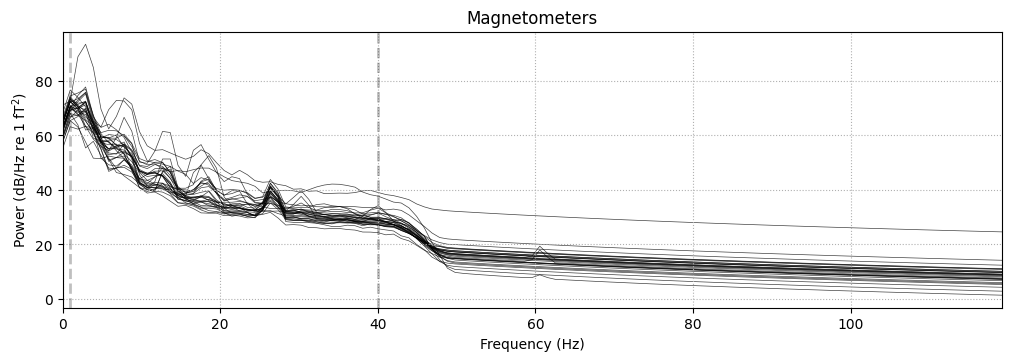

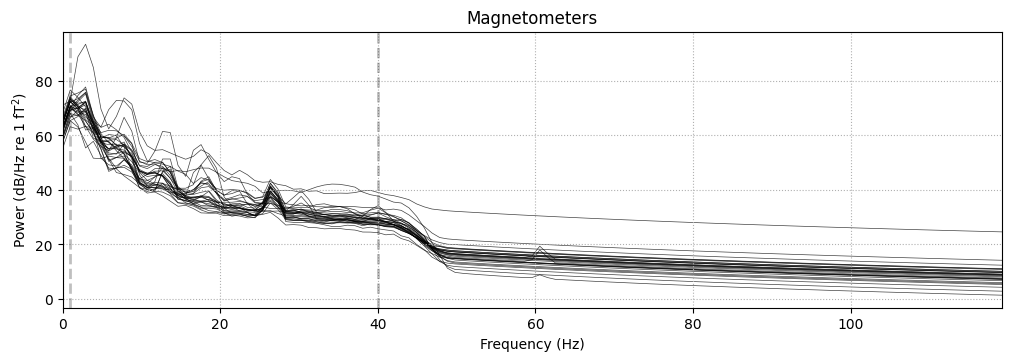

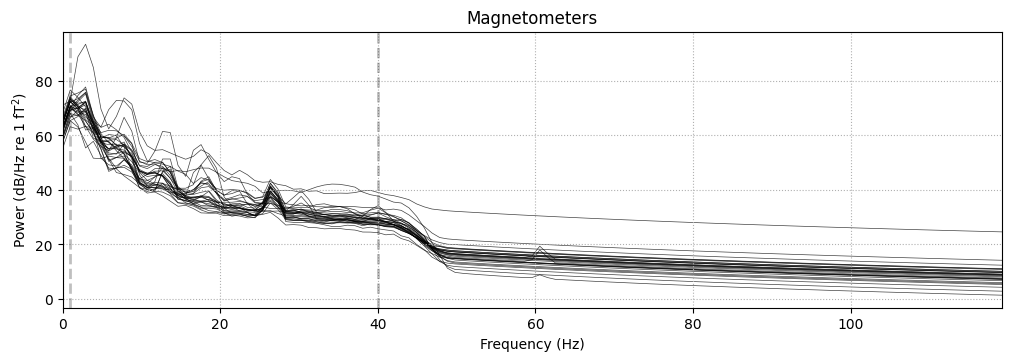

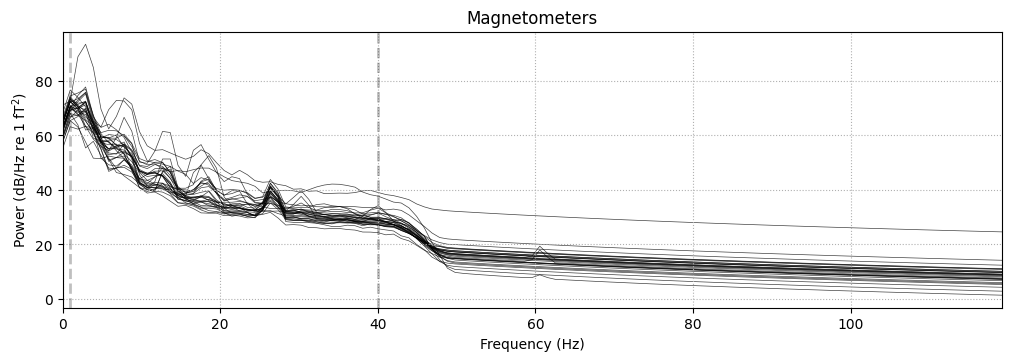

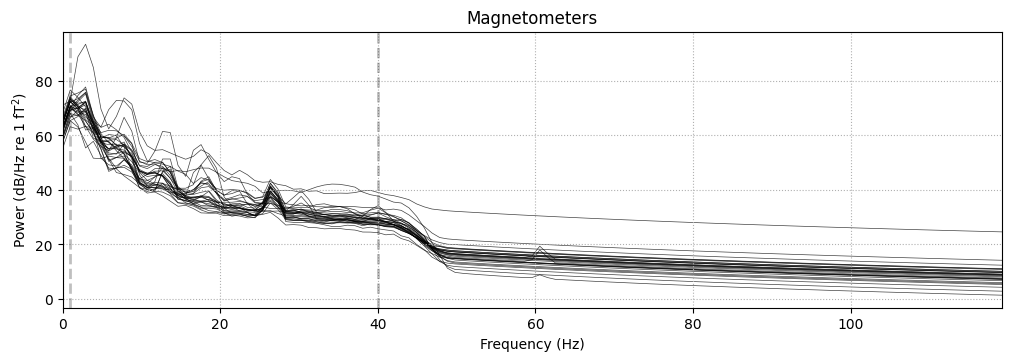

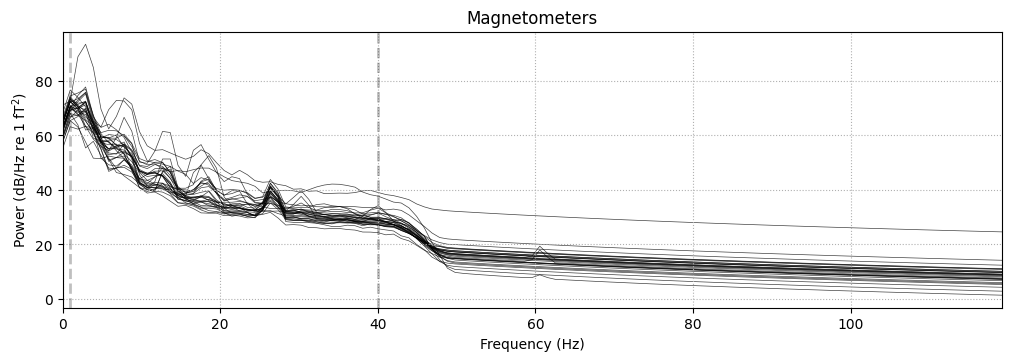

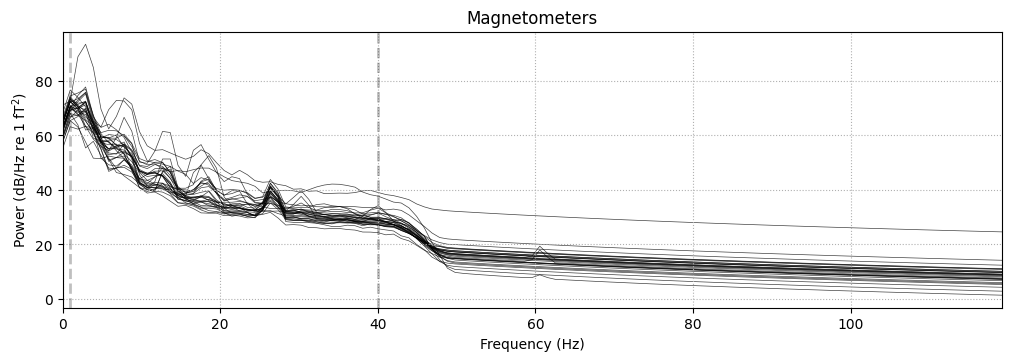

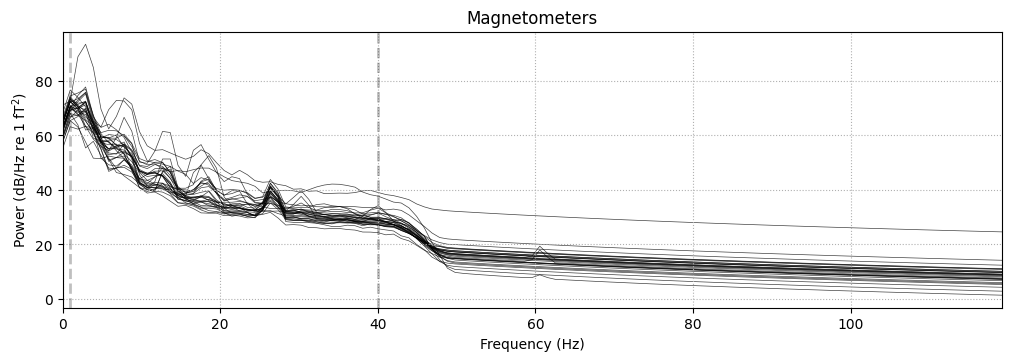

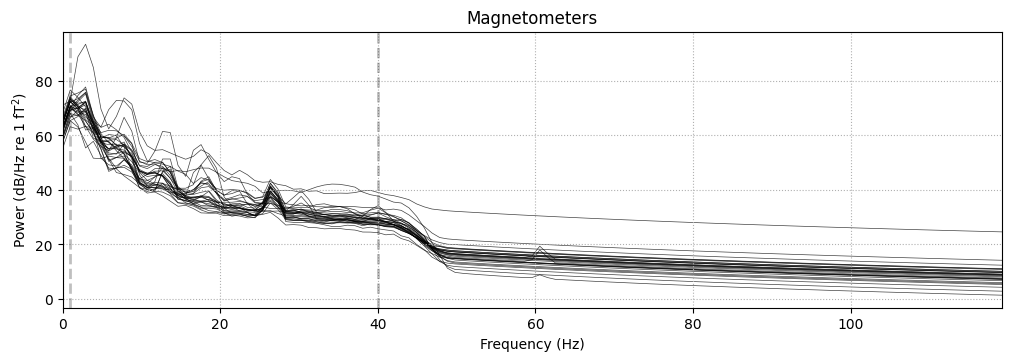

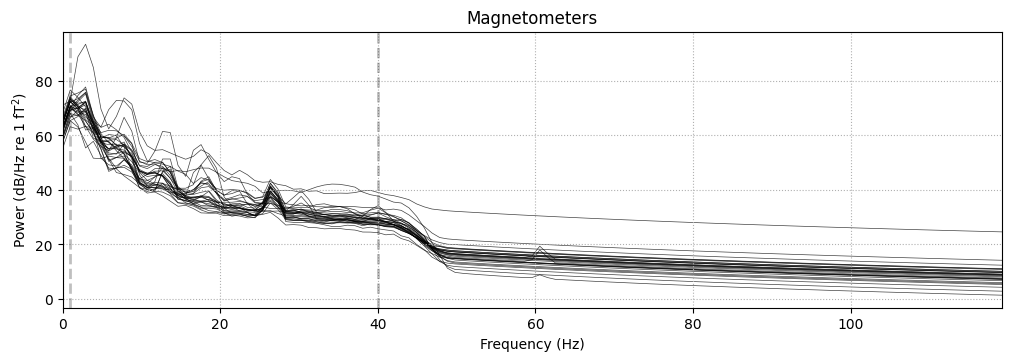

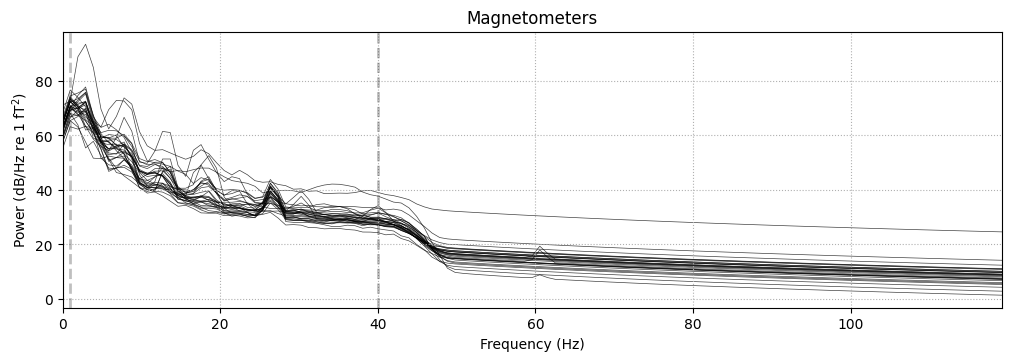

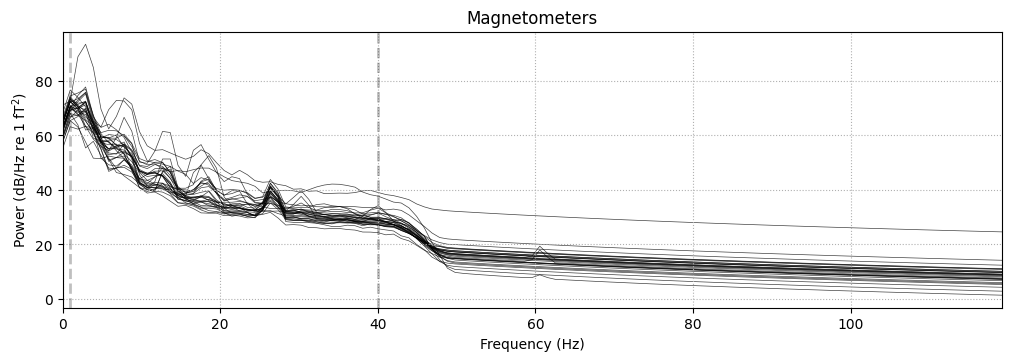

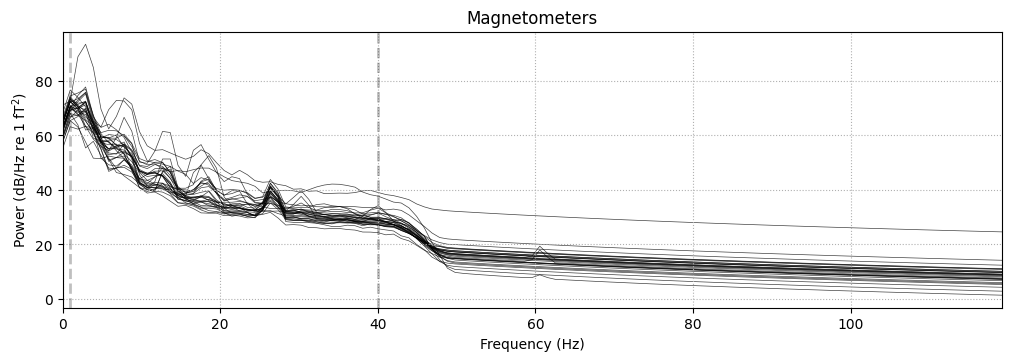

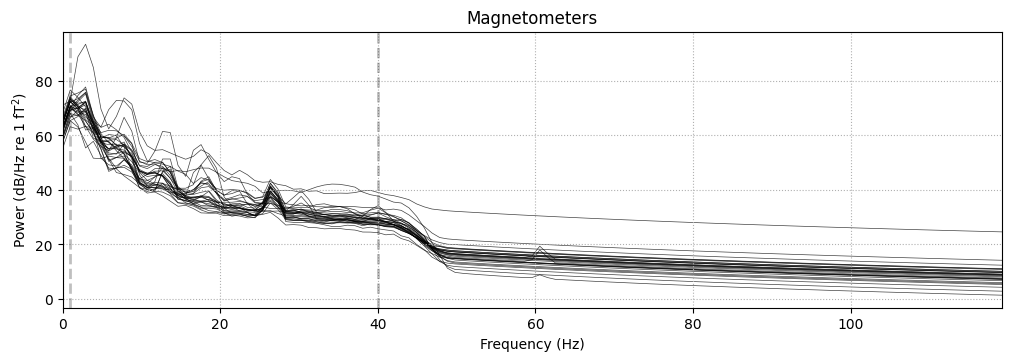

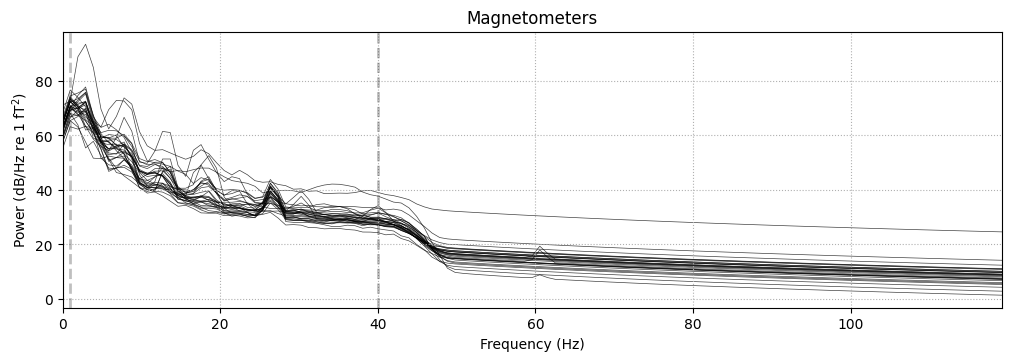

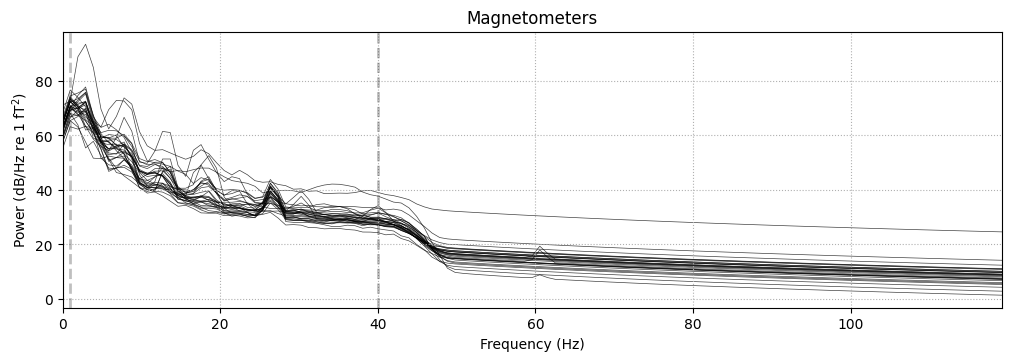

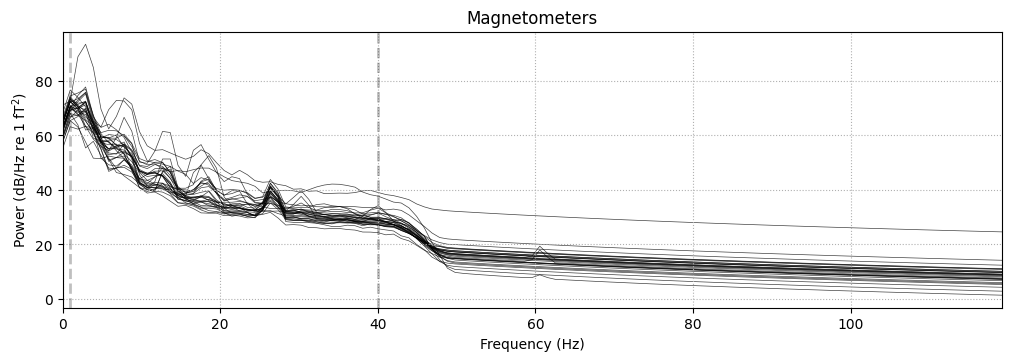

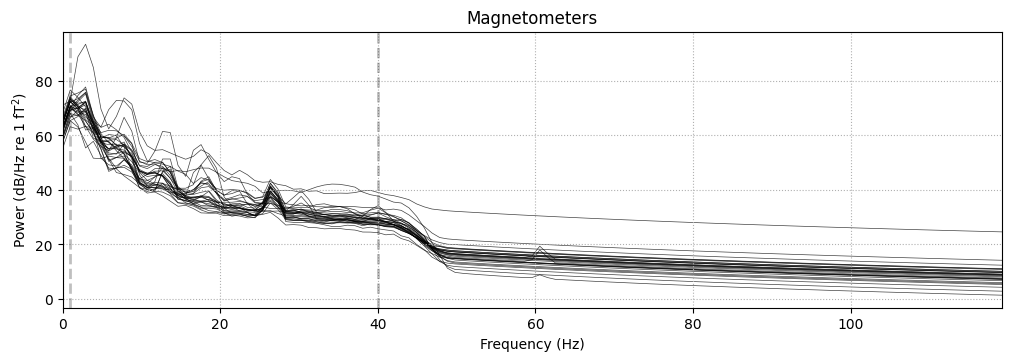

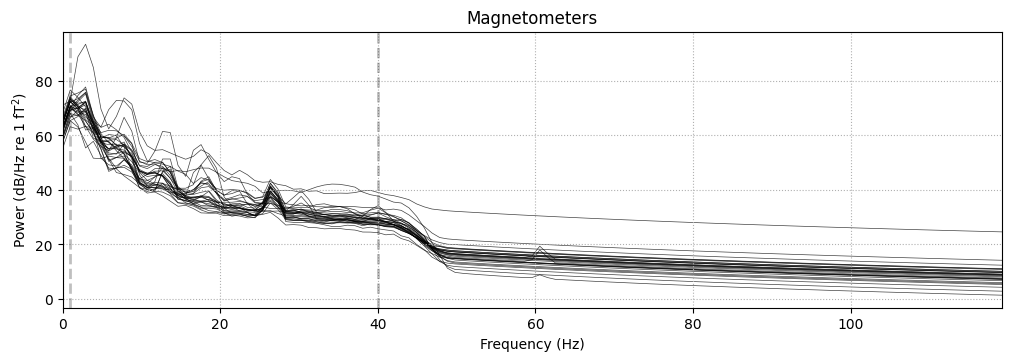

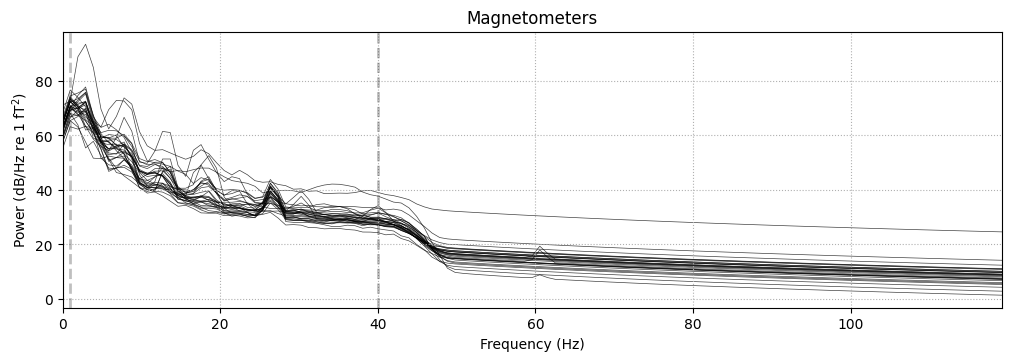

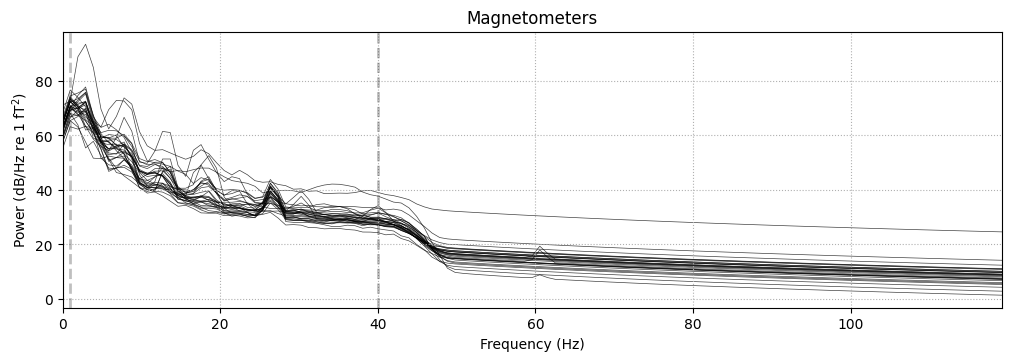

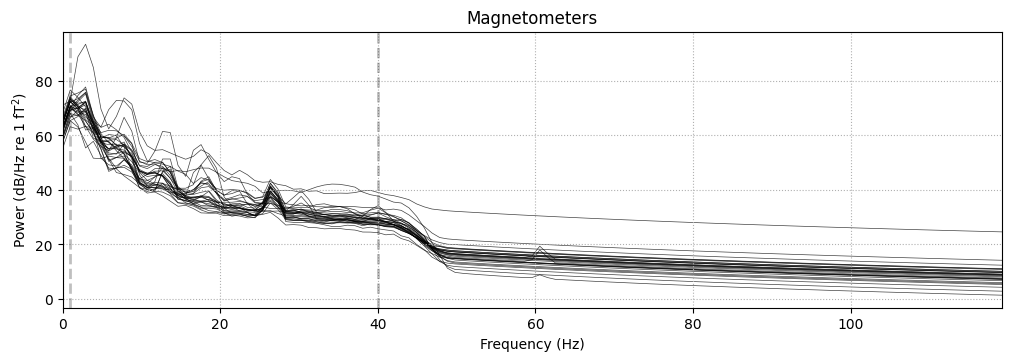

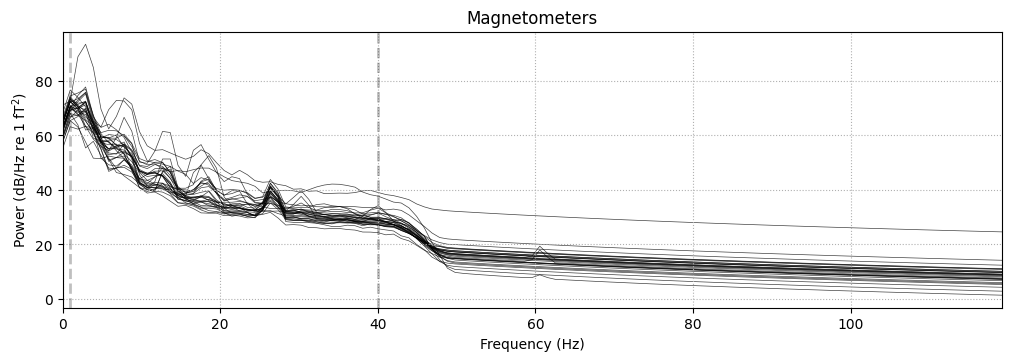

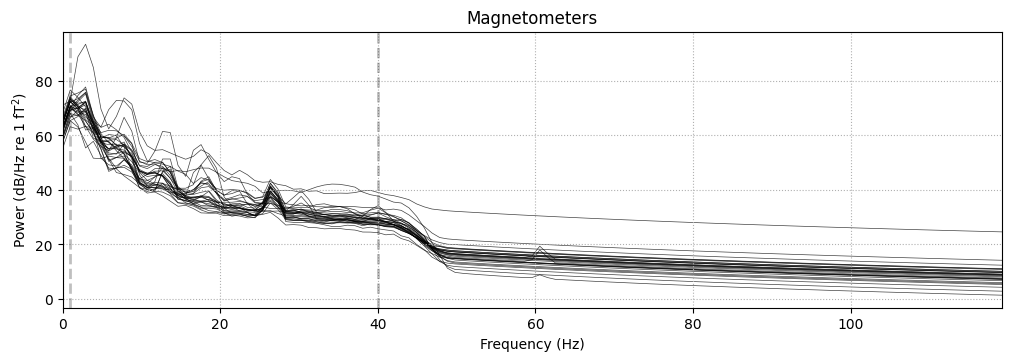

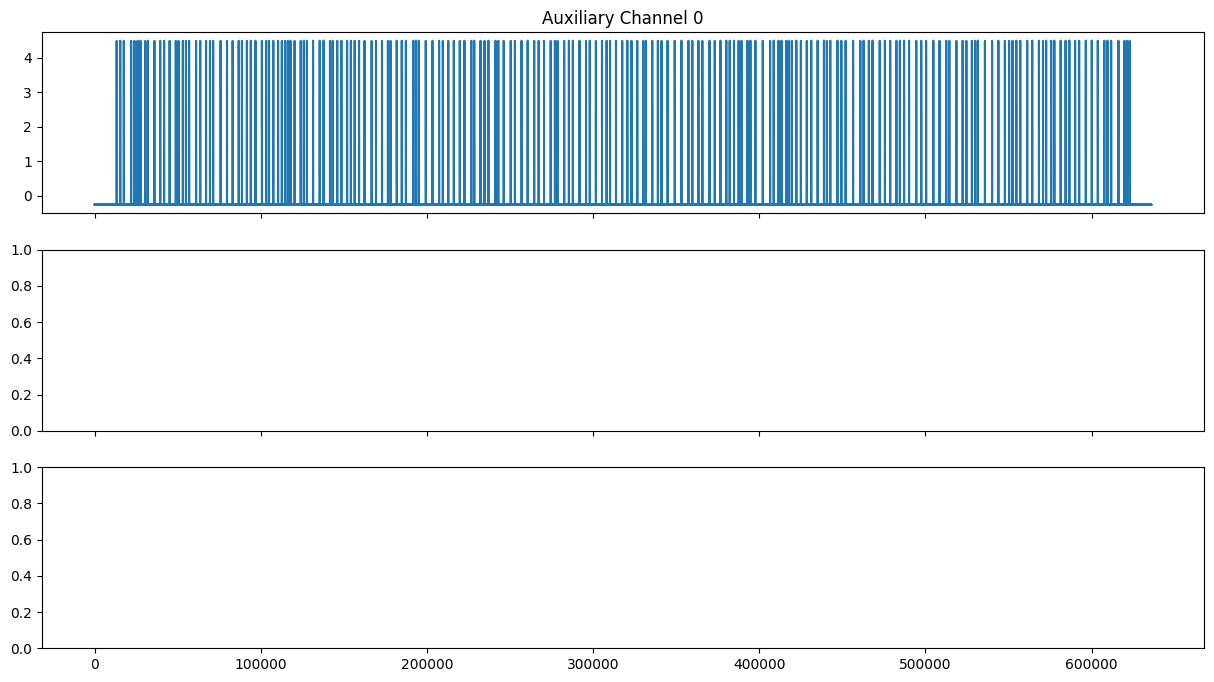

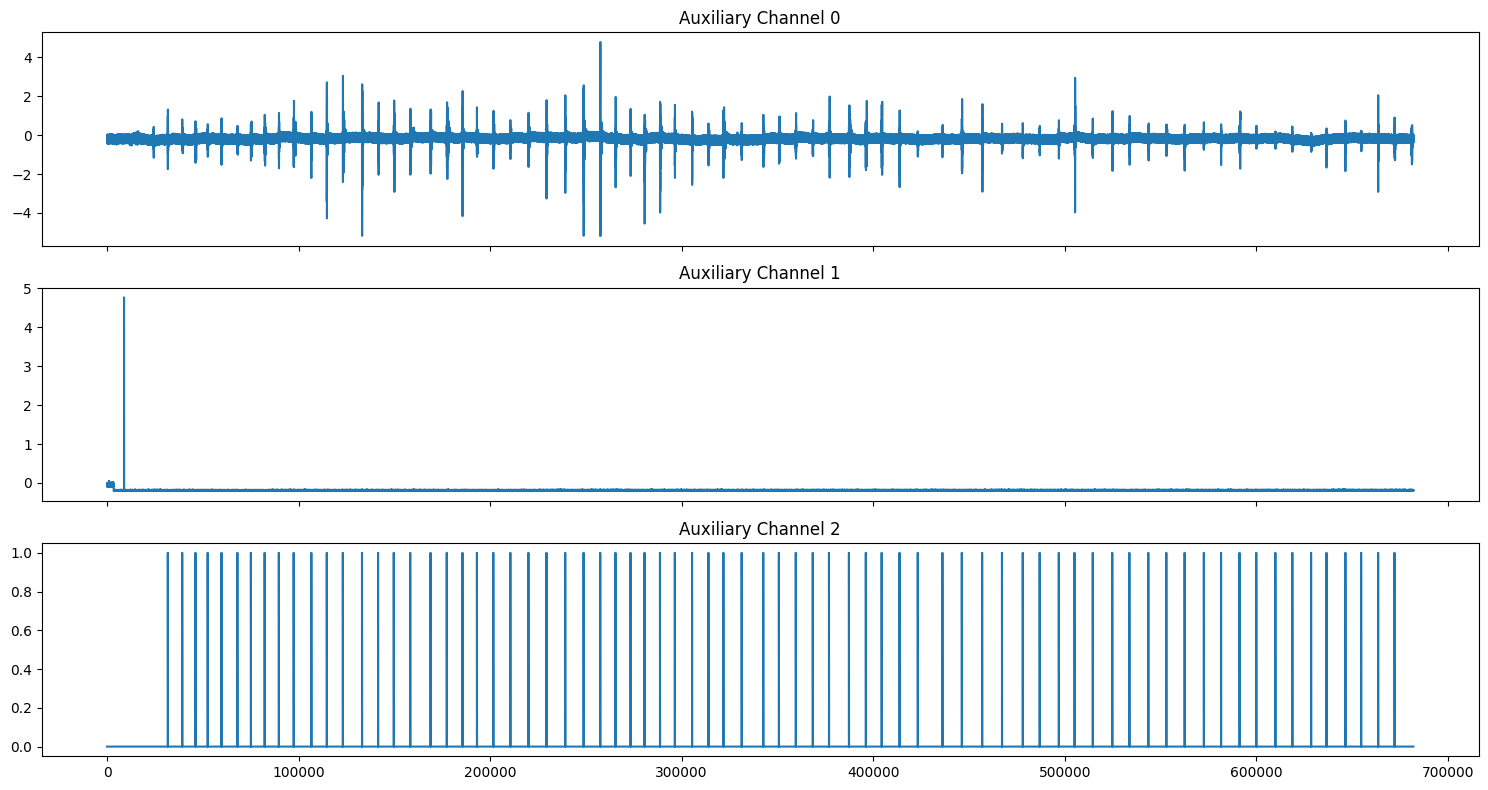

In [14]:
path = Path("../data/loaded/002/motor/run01.npz")
data = np.load(path, allow_pickle=True)

signals = data["signals"]
aux = data["aux"]

fig, ax = plt.subplots(
    3,
    1,
    figsize=(15, 8),
    sharex=True
)

for i in range(3):
    ax[i].plot(aux[i])
    ax[i].set_title(f"Auxiliary Channel {i}")

plt.tight_layout()
plt.show()

- auxiliary channel 0: physiological recording (likely the EMG, muscle activity from the finger movement
- auxiliary channel 1: unsure
- auxiliary channel 0: detected movement trigger


In [16]:
for file in files:
    
    task = file.parent.name.lower()

    print(task)
    print(aux.shape)
    if task == "motor":
        trigger = aux[2]
    else:
        trigger = aux[0]

auditory
(1, 636000)
auditory
(1, 636000)
motor
(1, 636000)


IndexError: index 2 is out of bounds for axis 0 with size 1

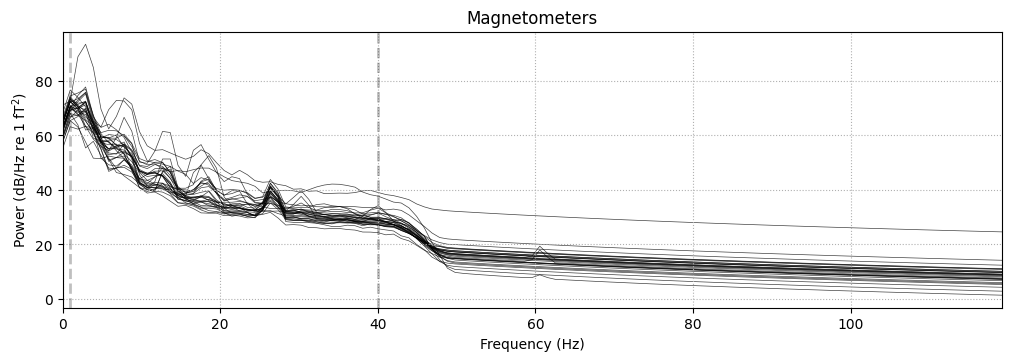

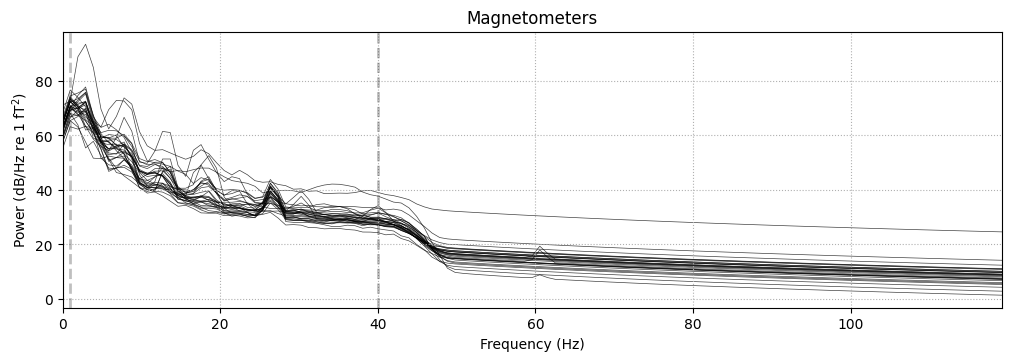

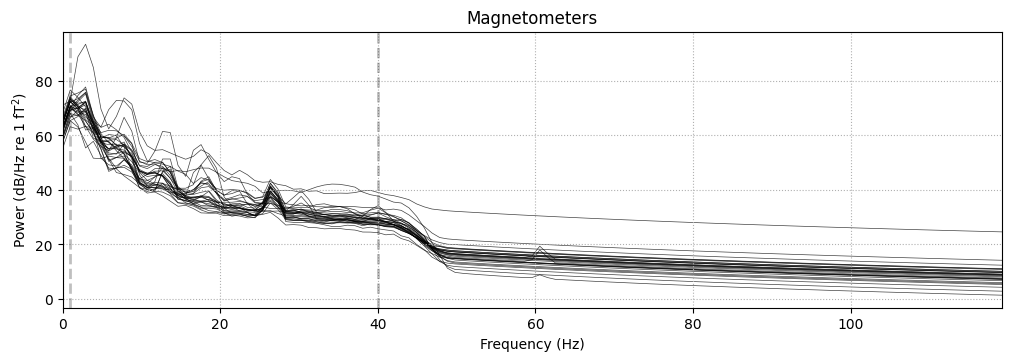

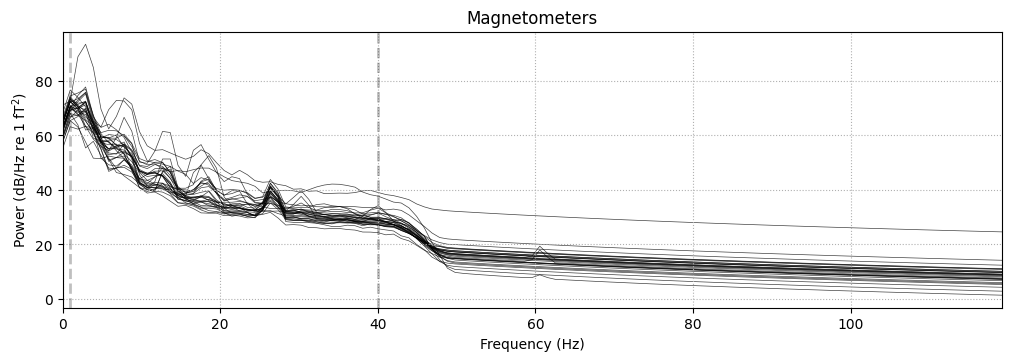

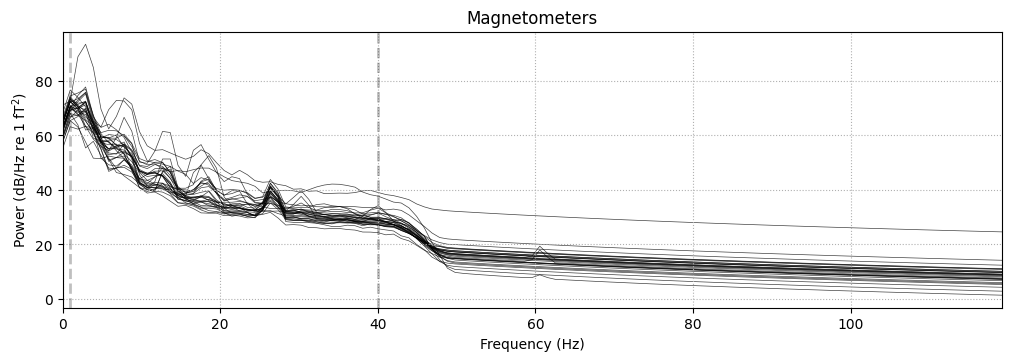

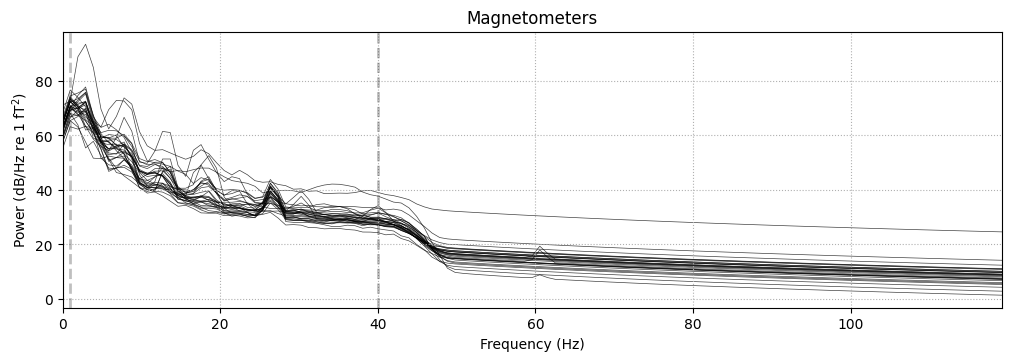

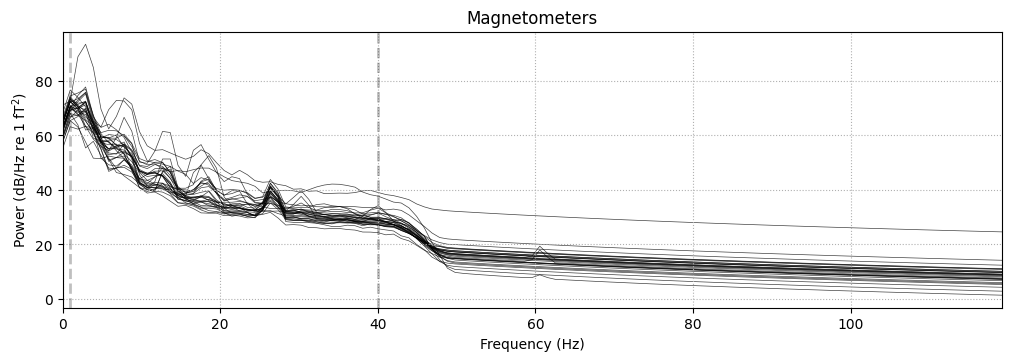

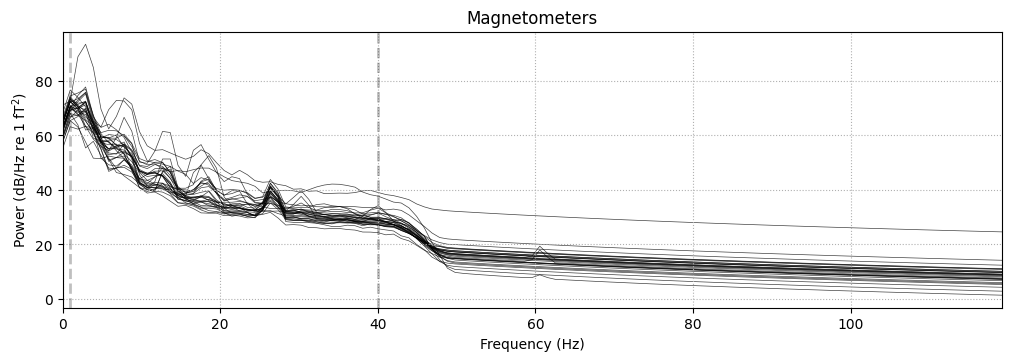

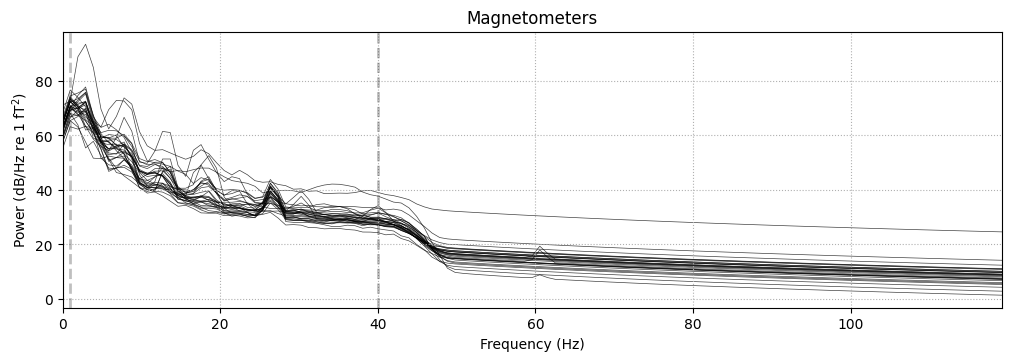

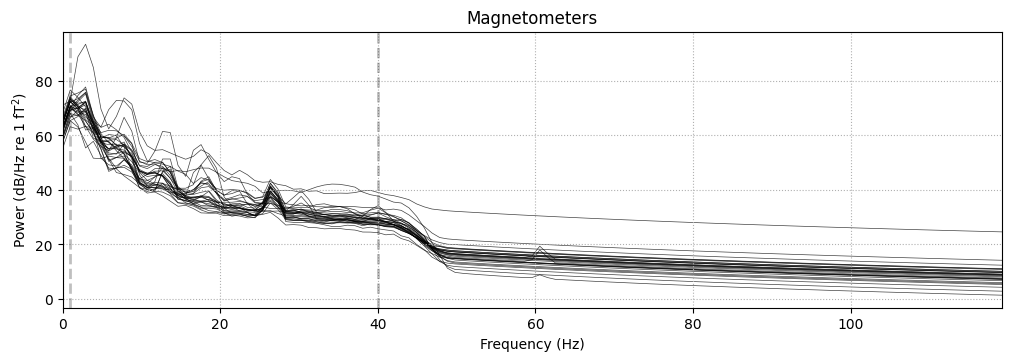

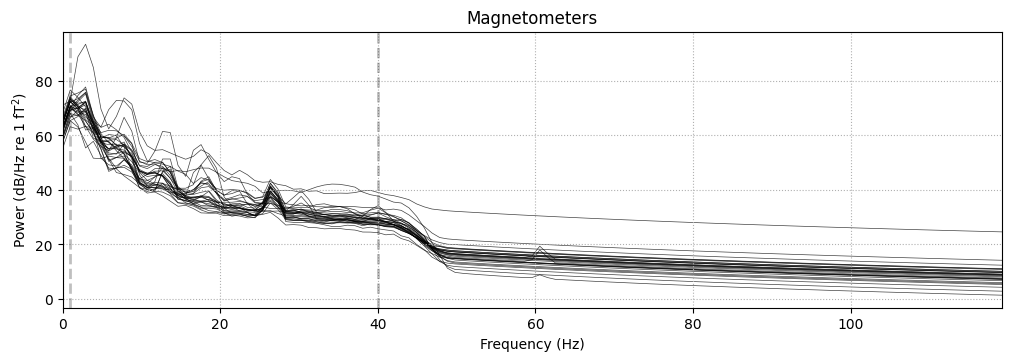

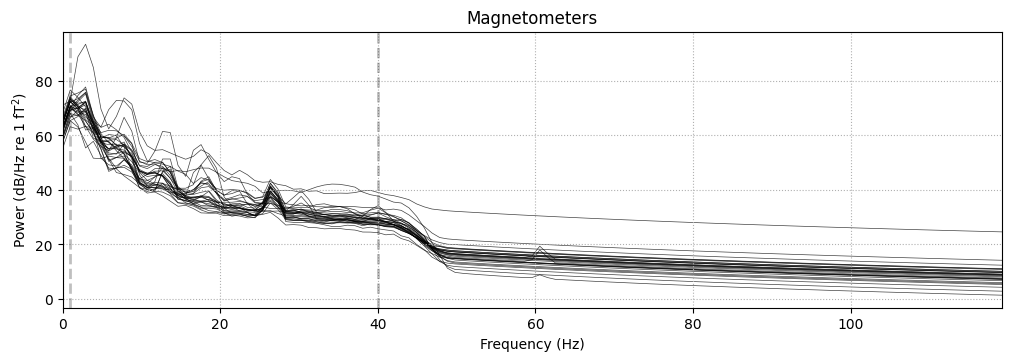

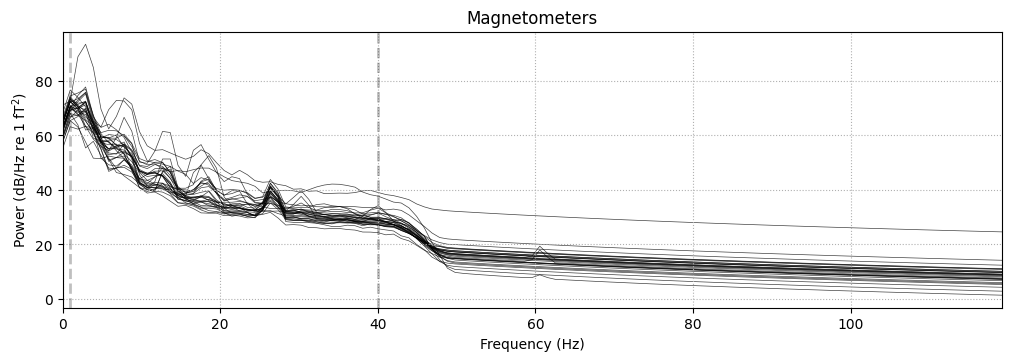

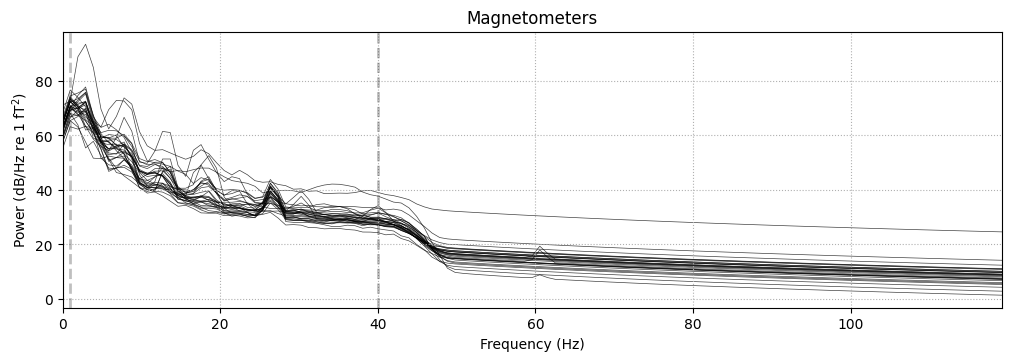

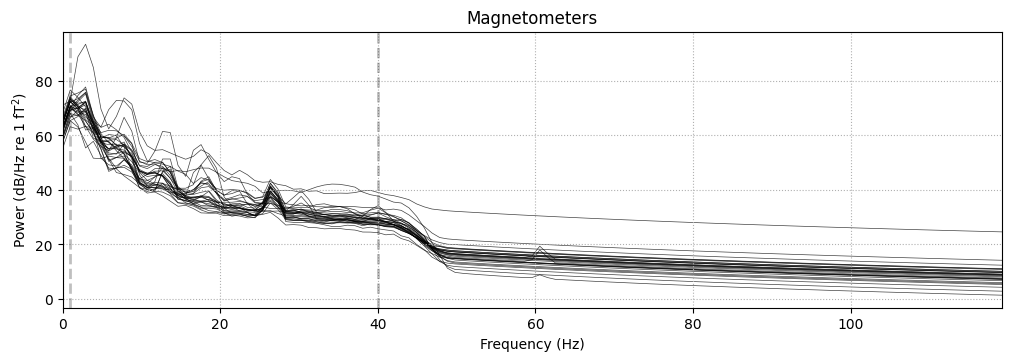

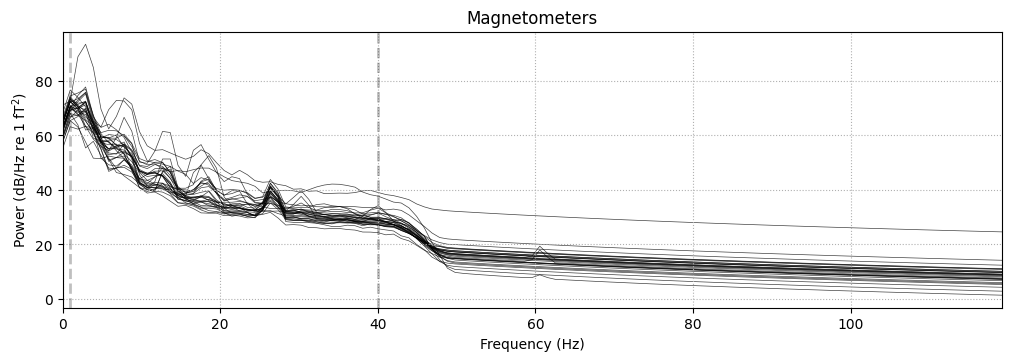

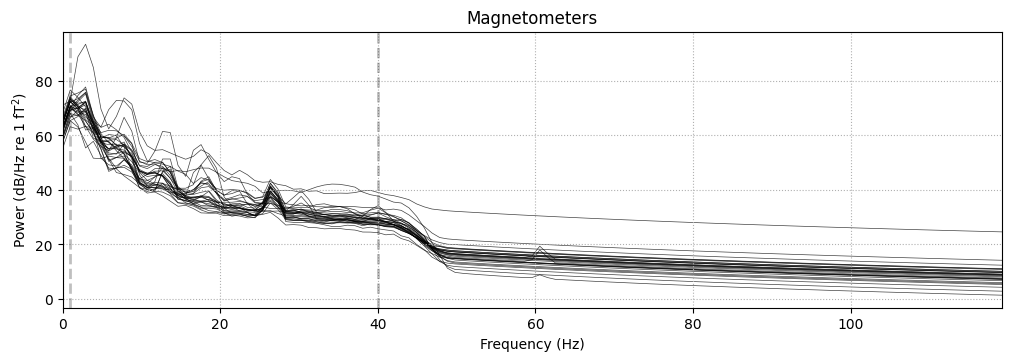

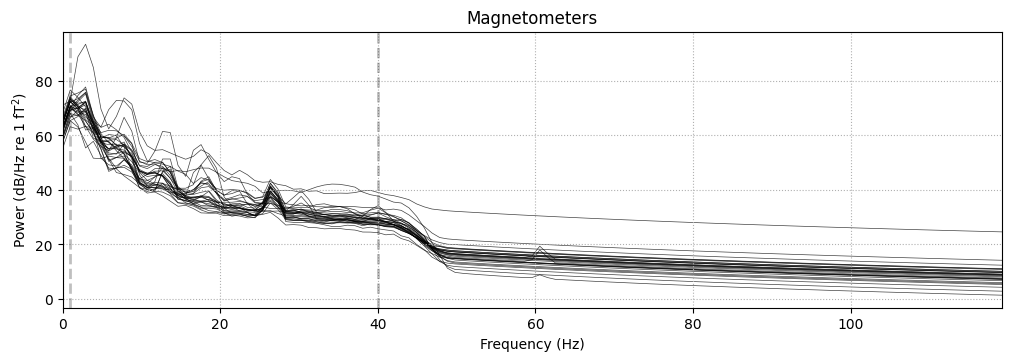

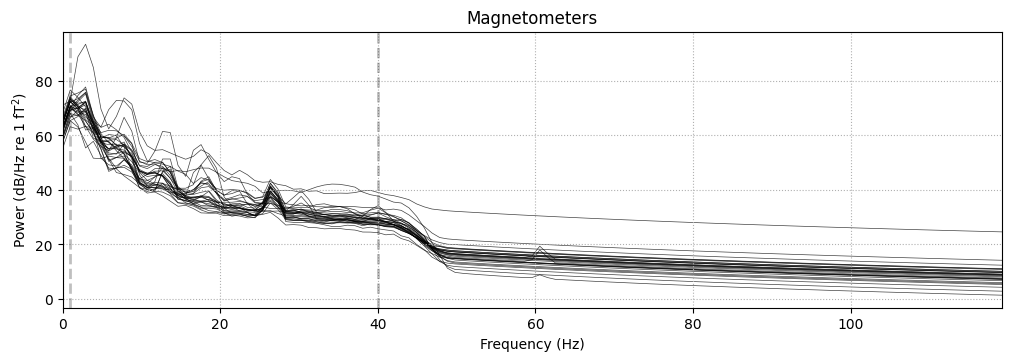

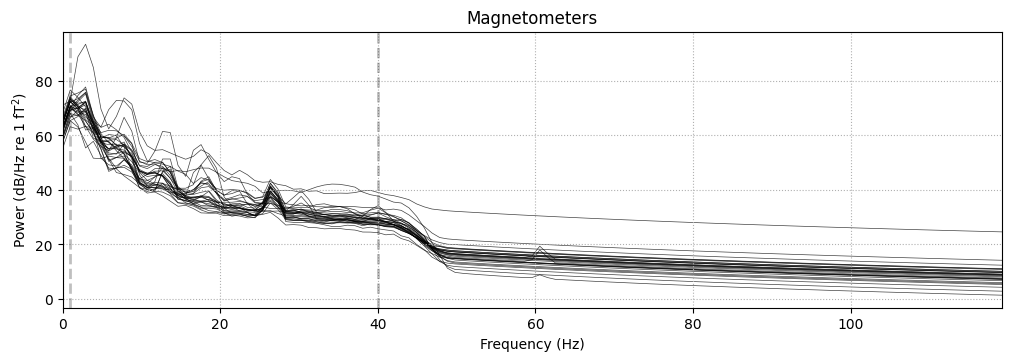

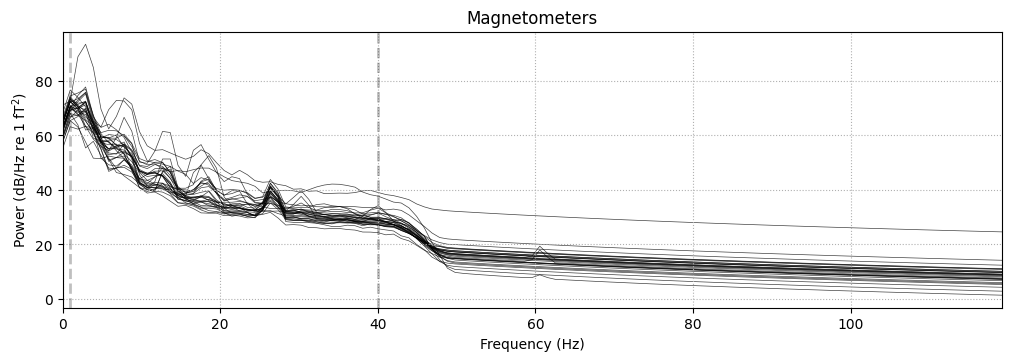

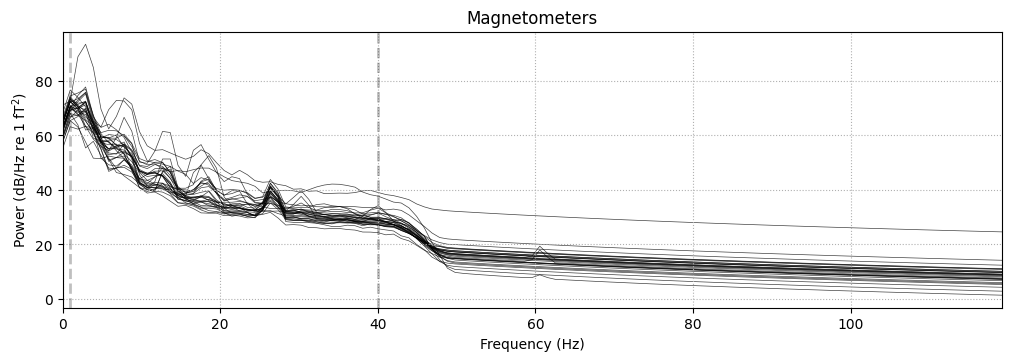

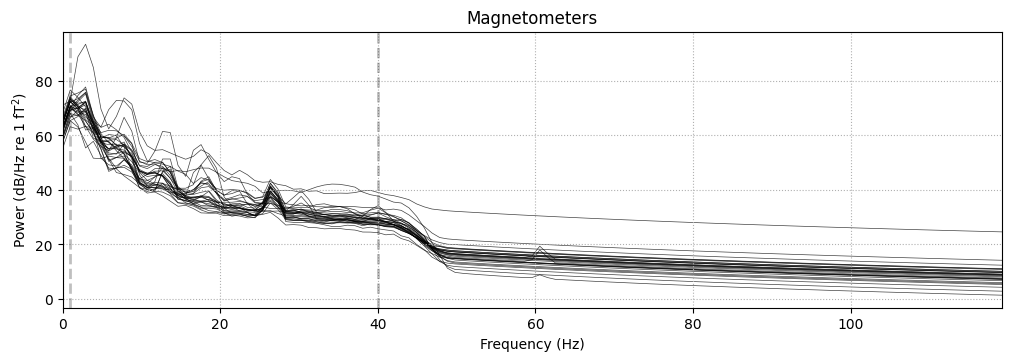

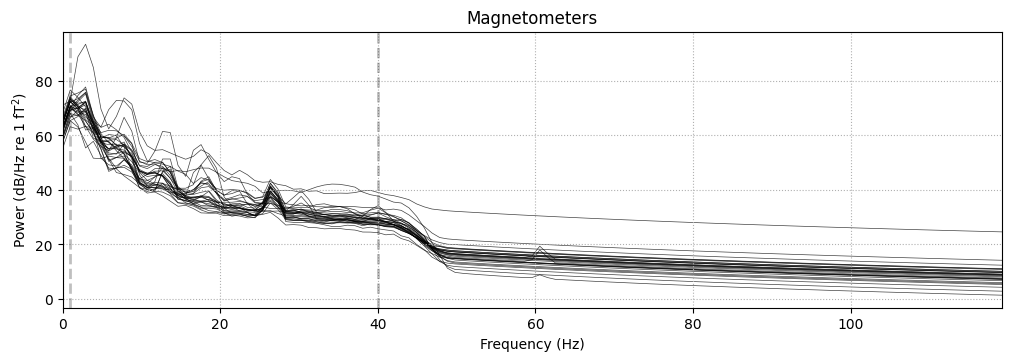

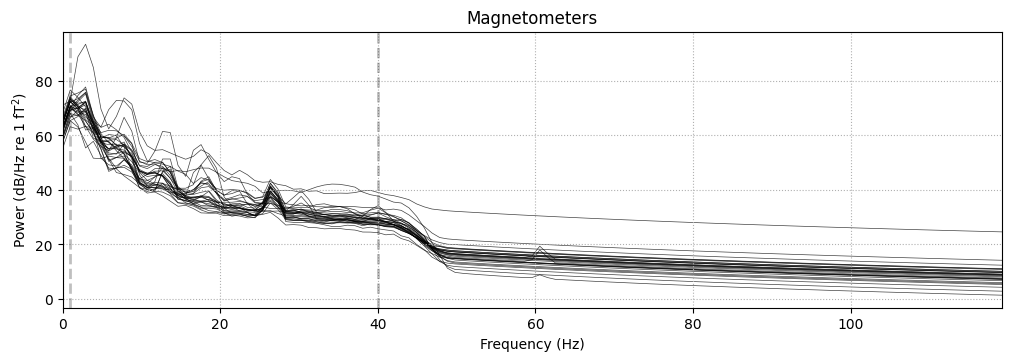

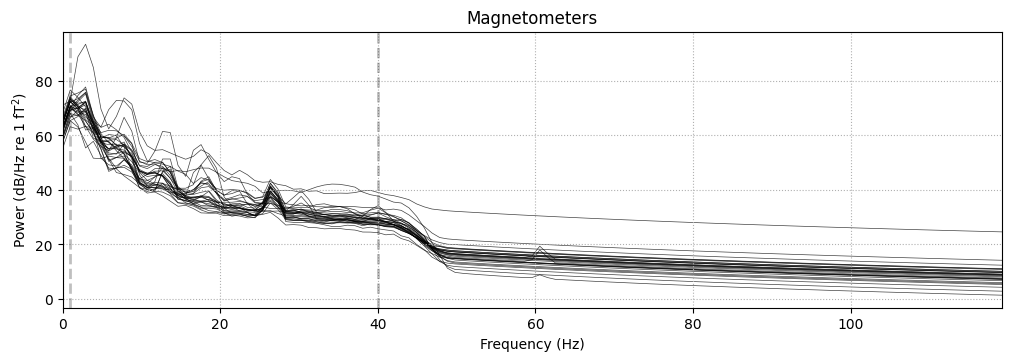

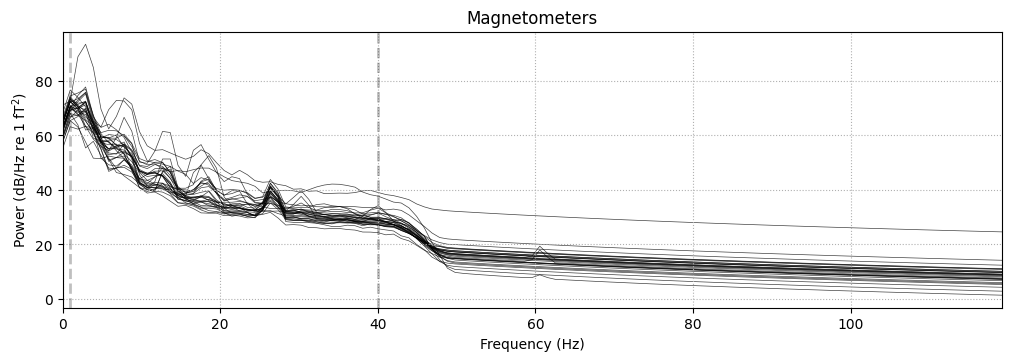

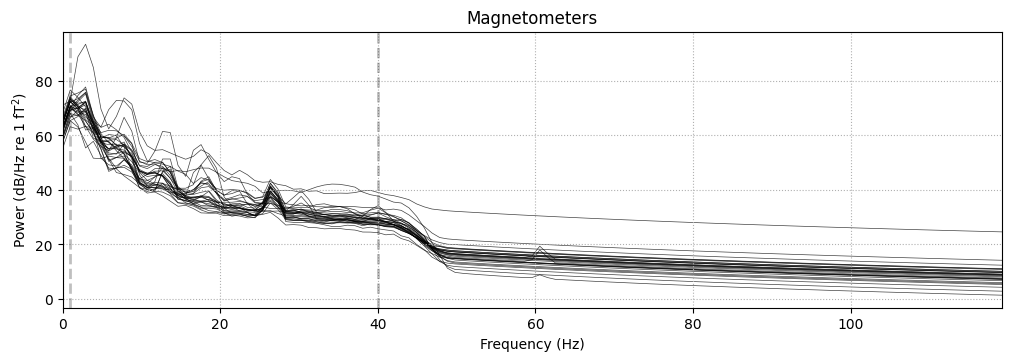

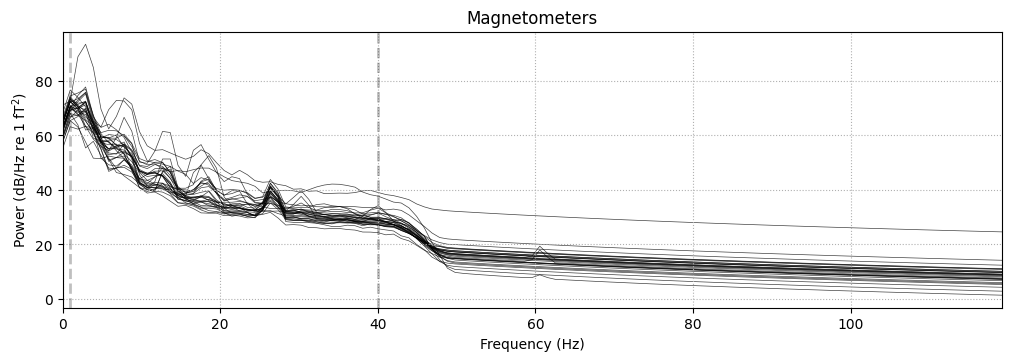

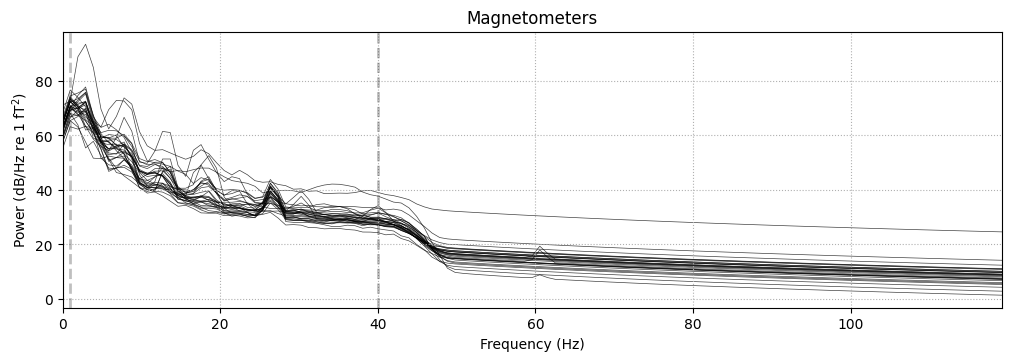

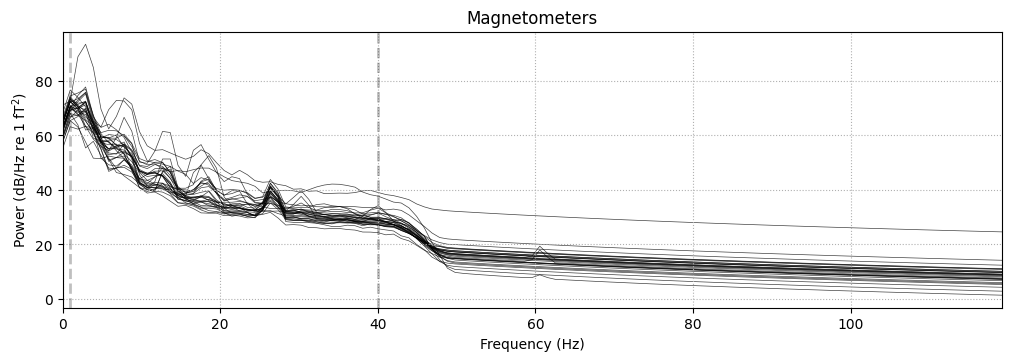

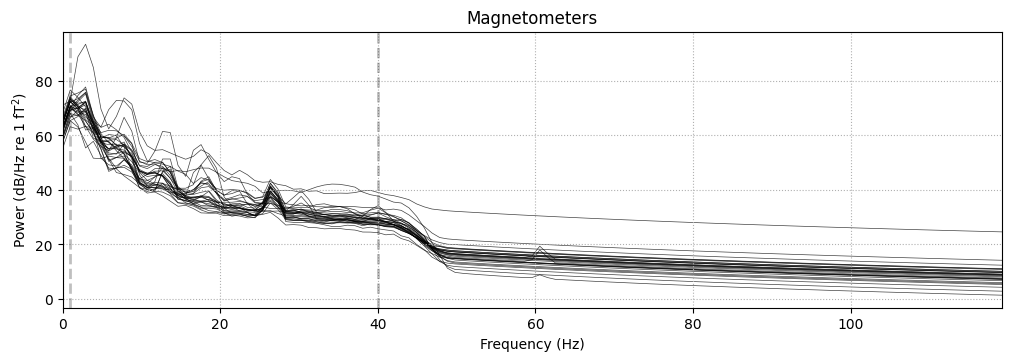

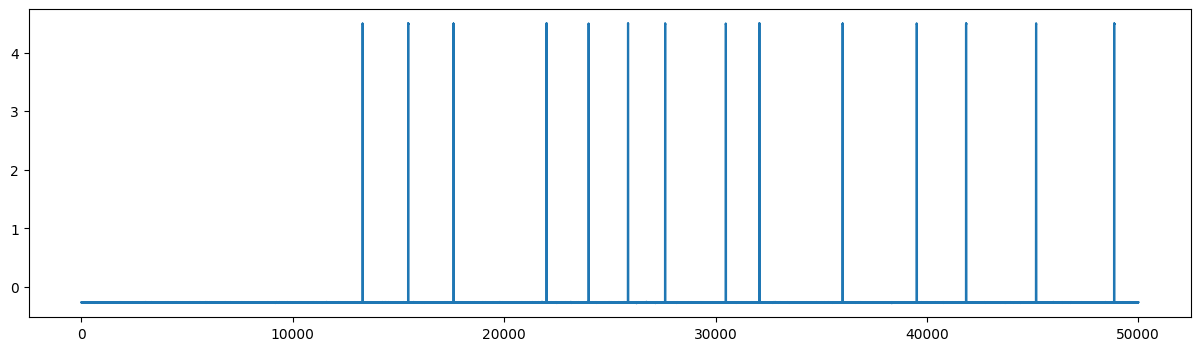

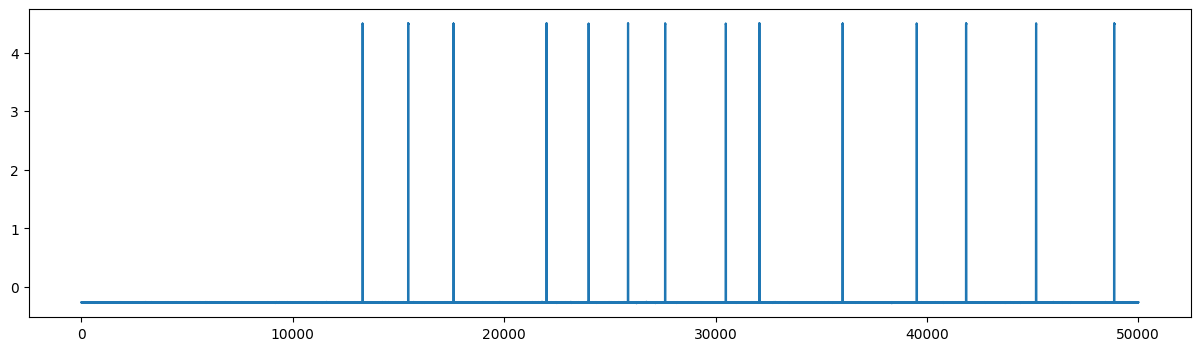

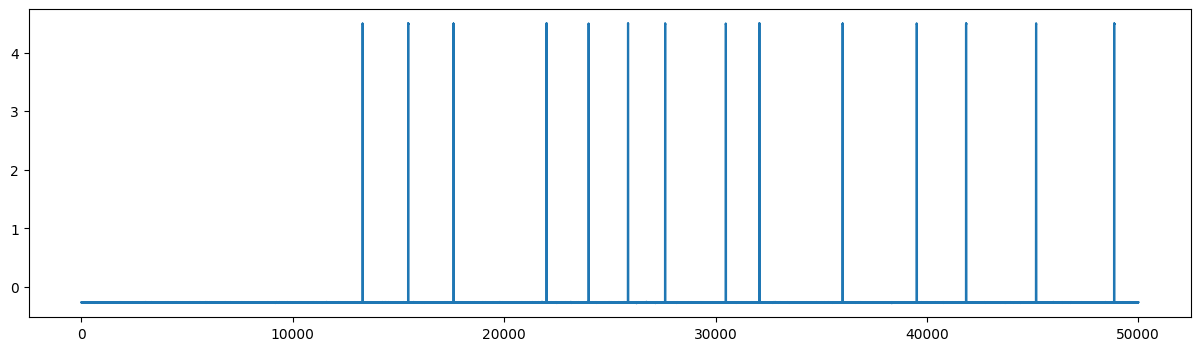

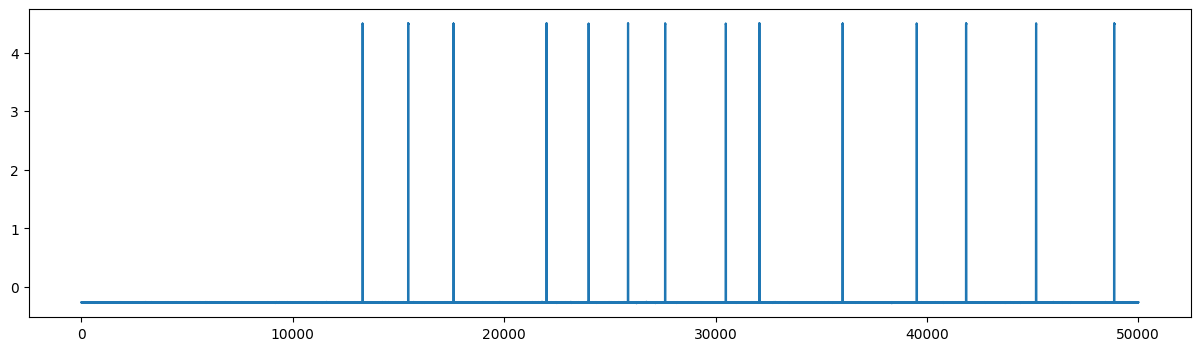

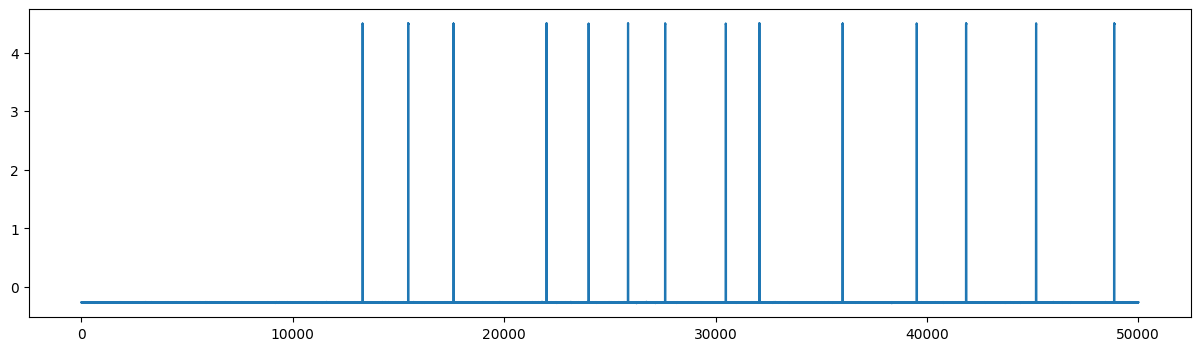

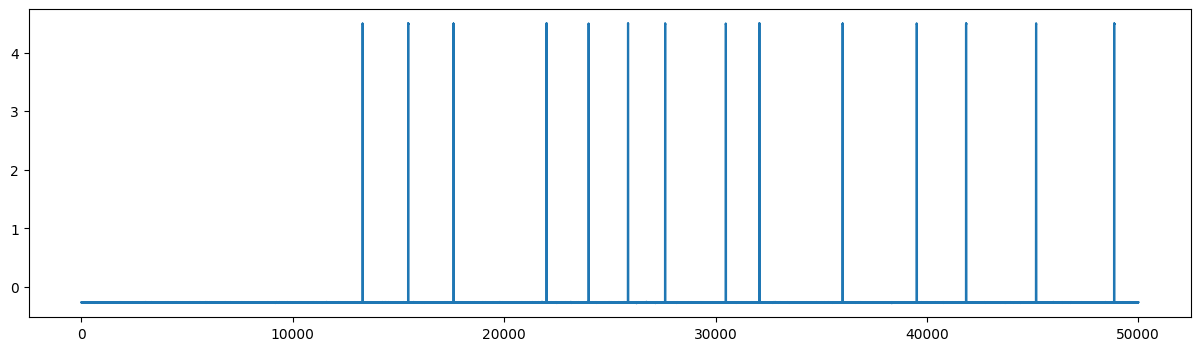

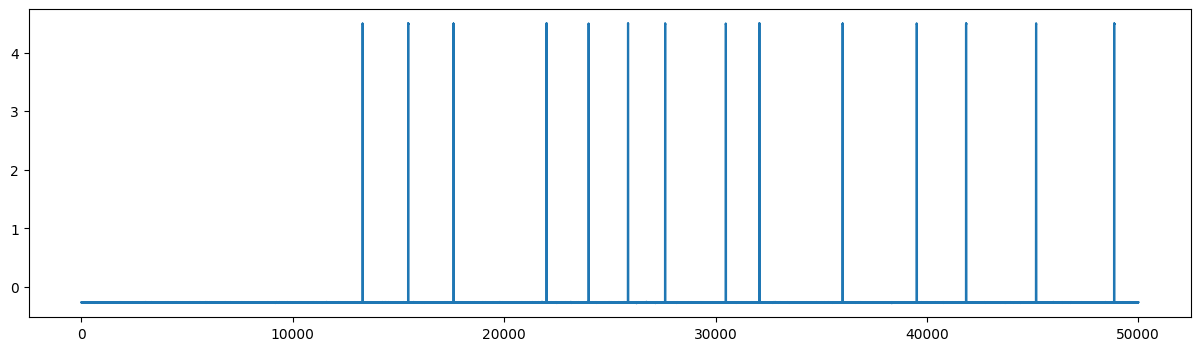

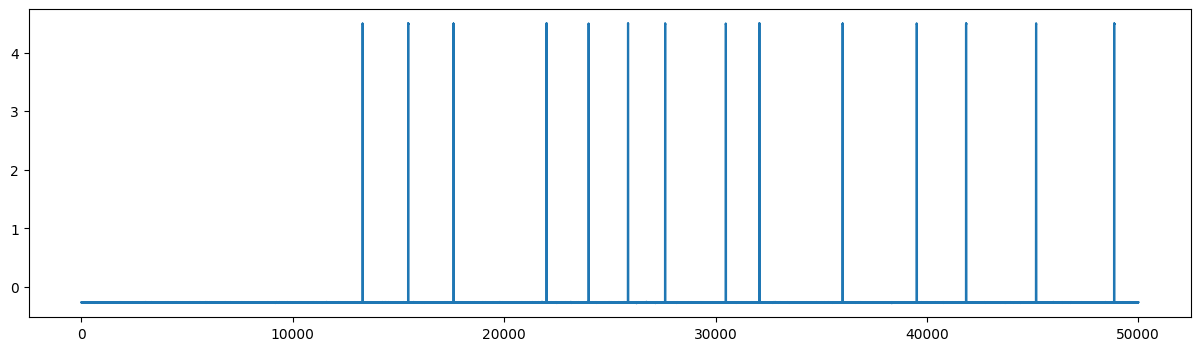

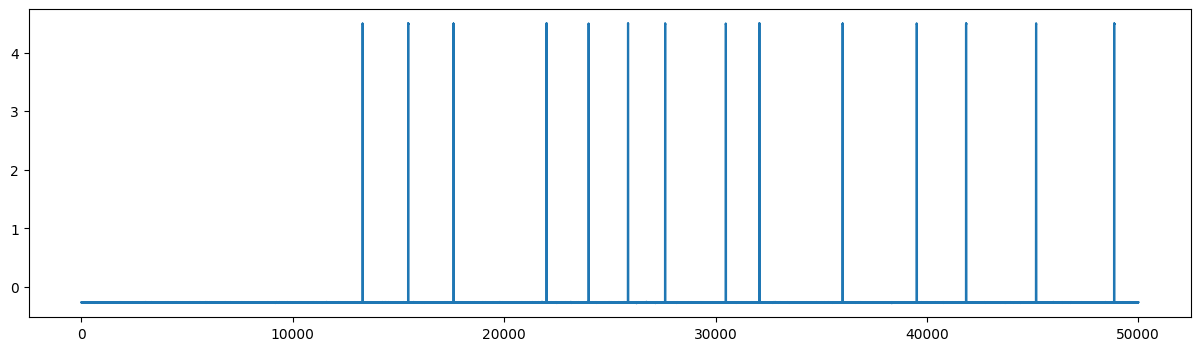

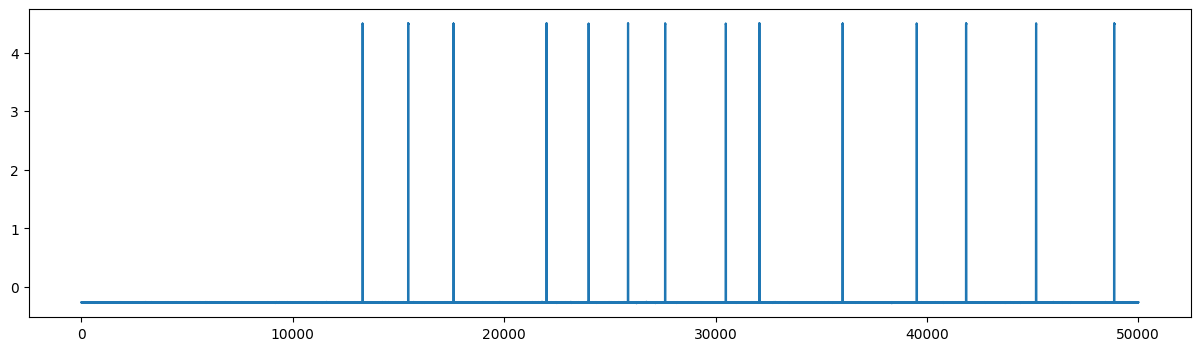

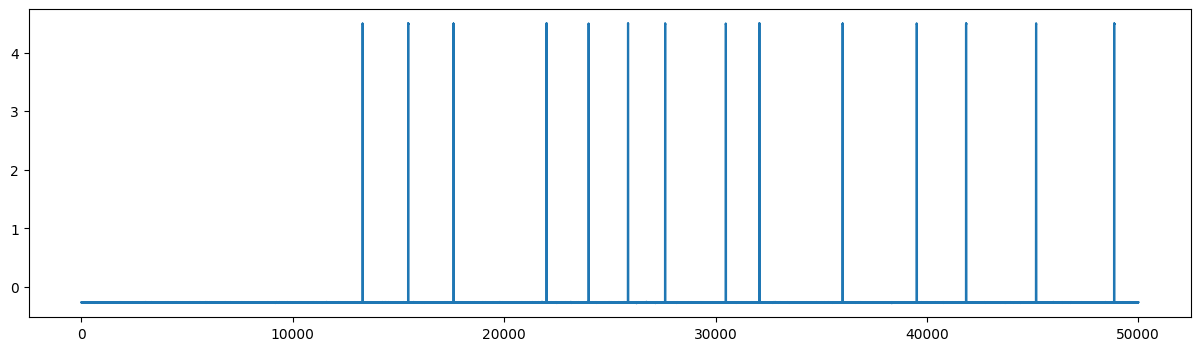

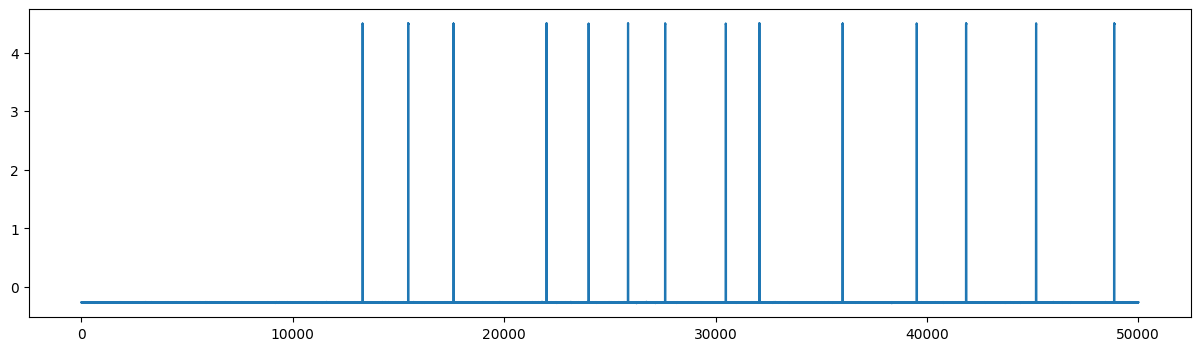

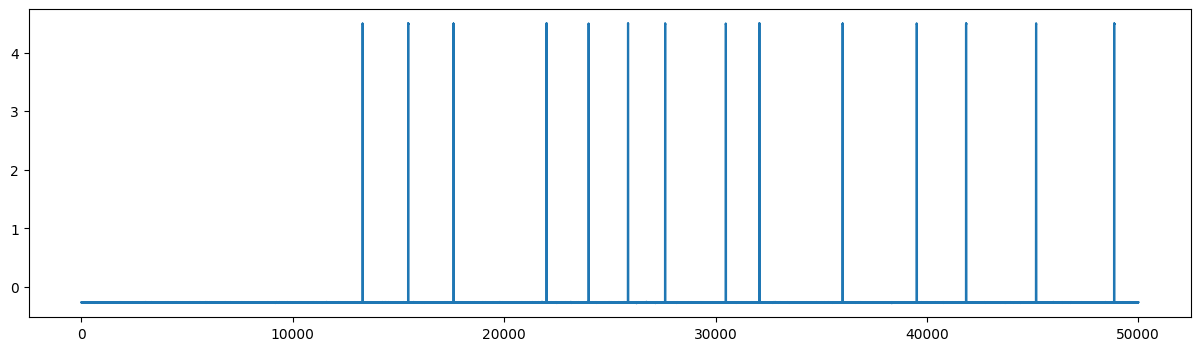

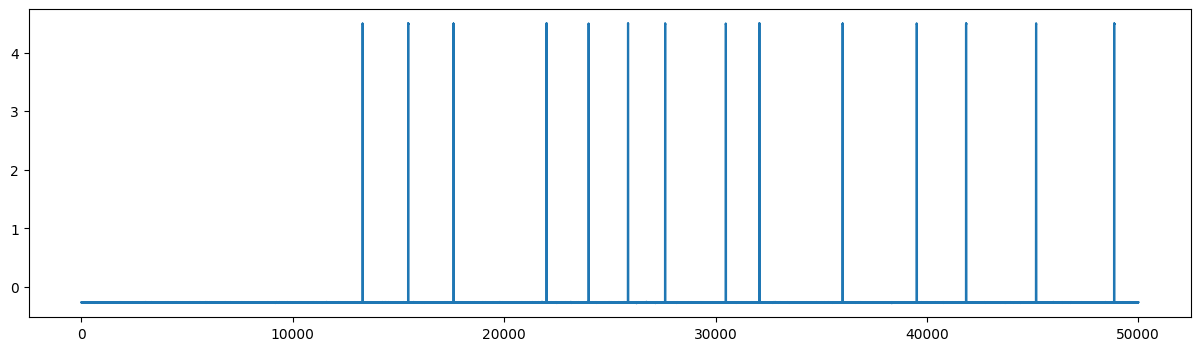

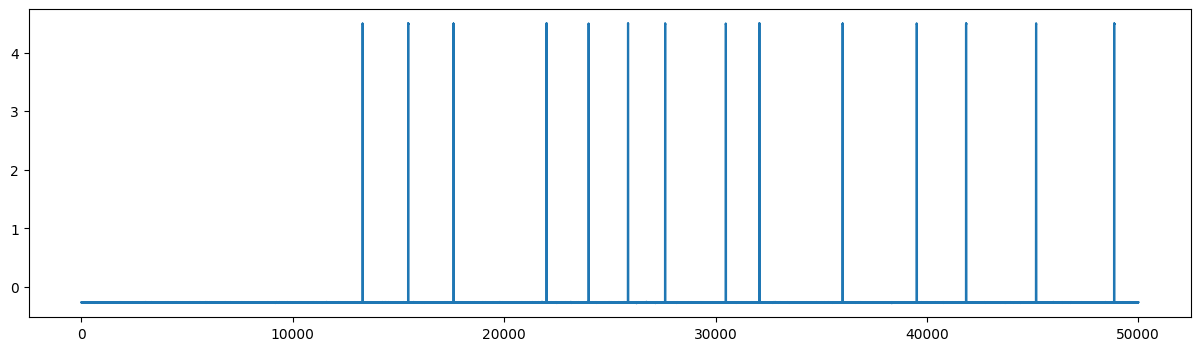

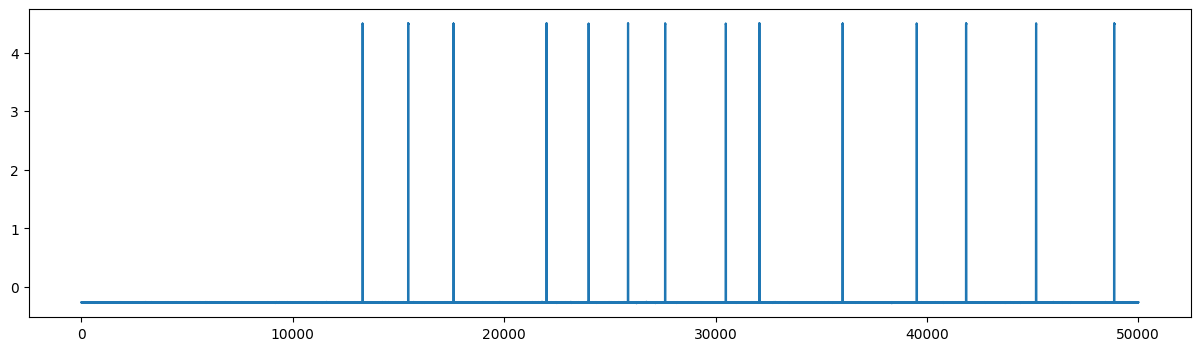

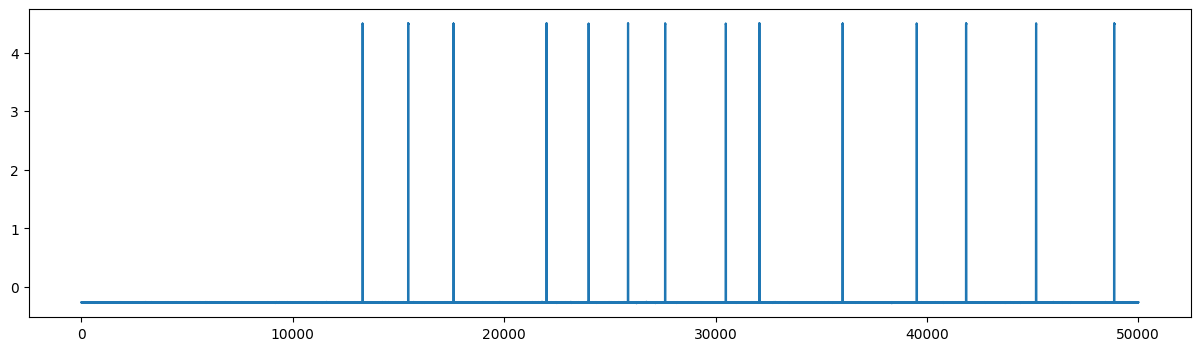

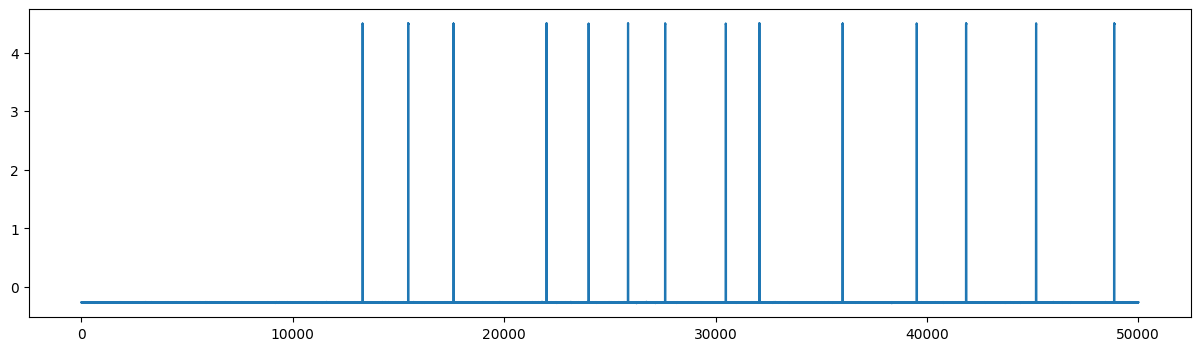

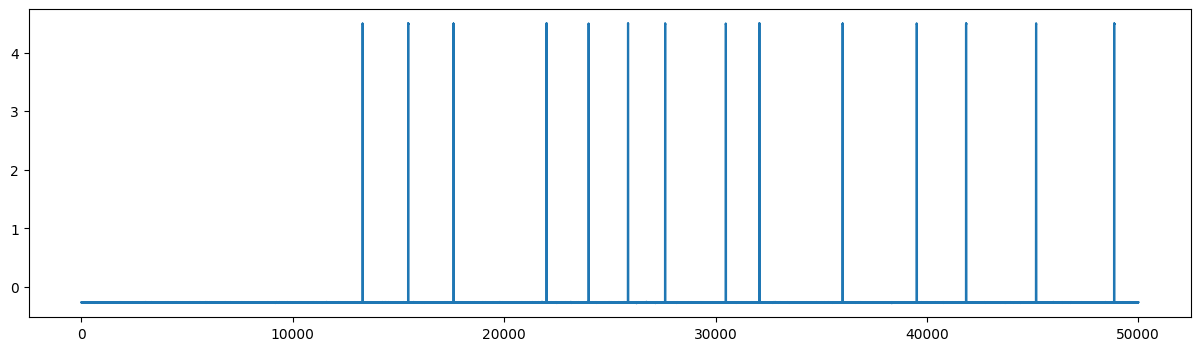

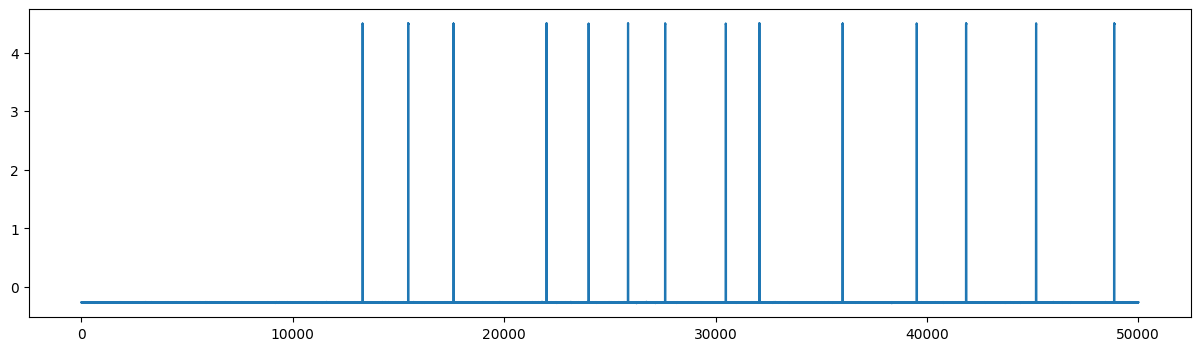

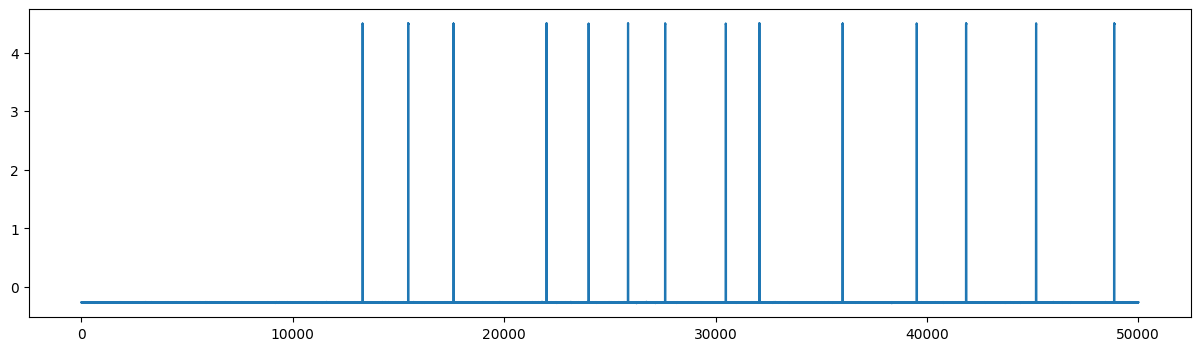

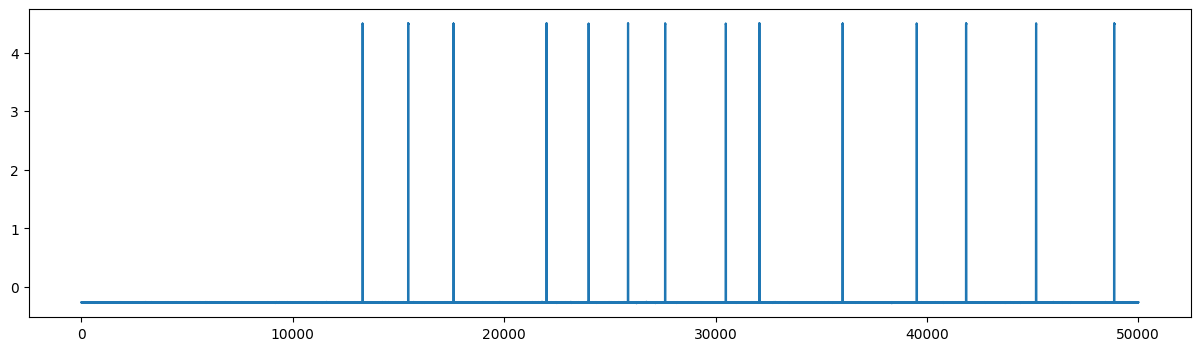

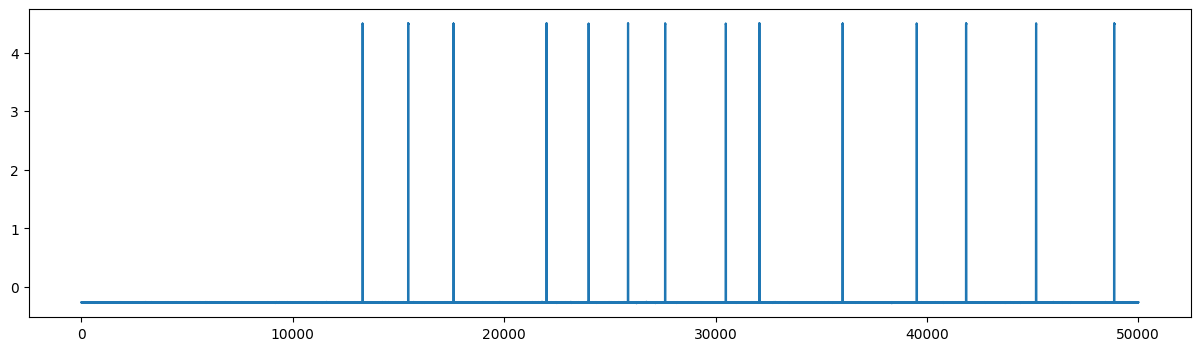

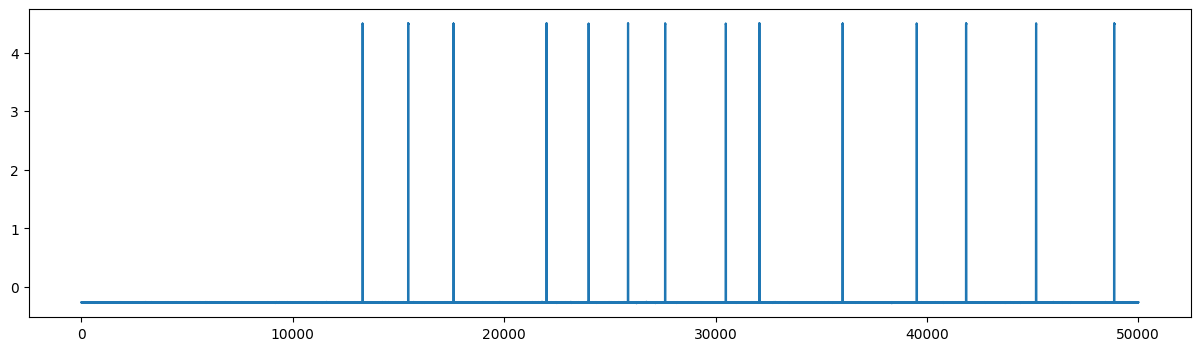

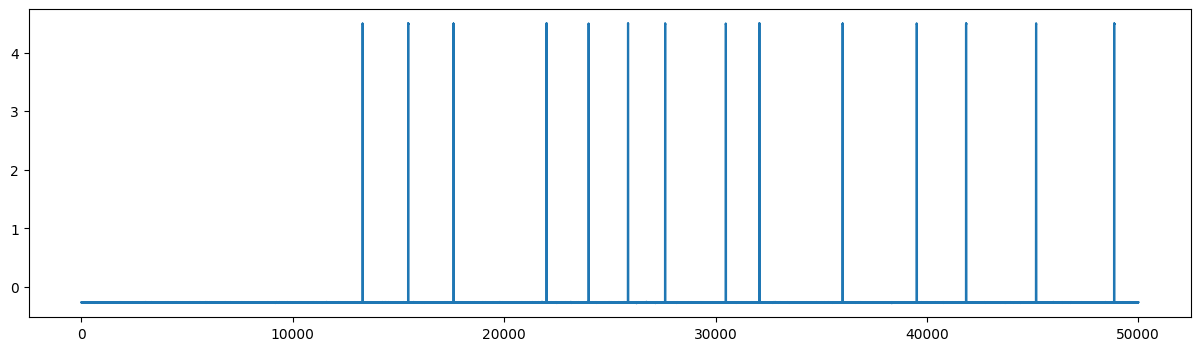

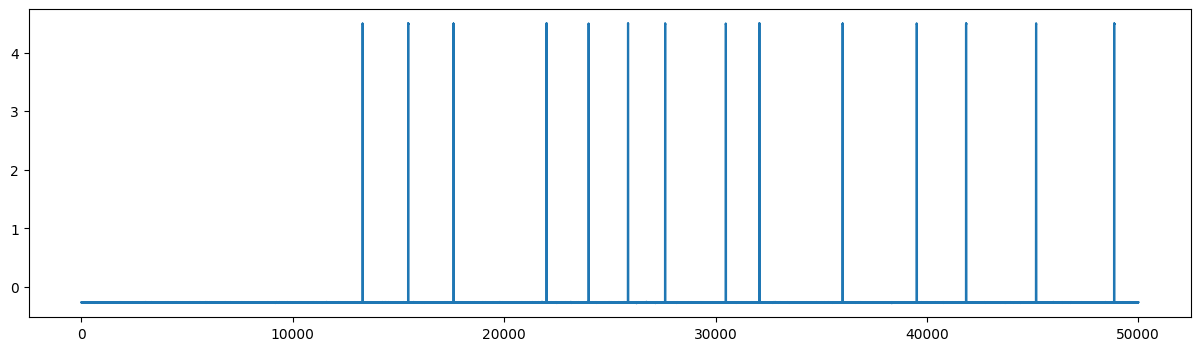

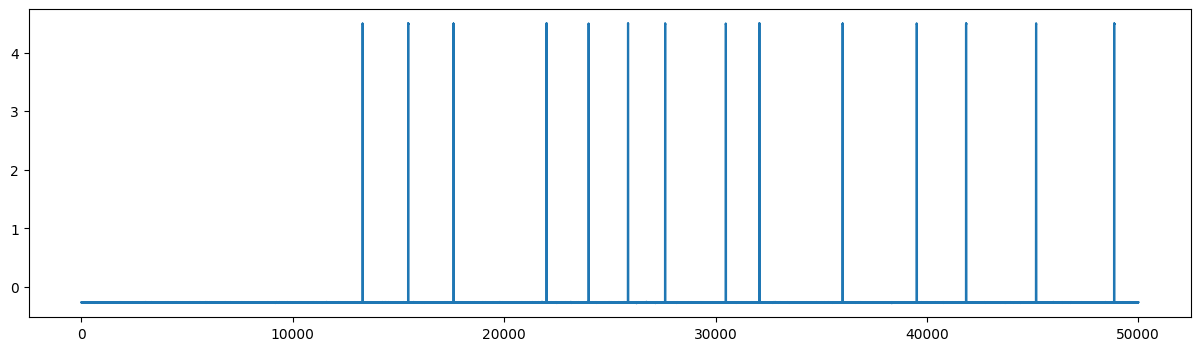

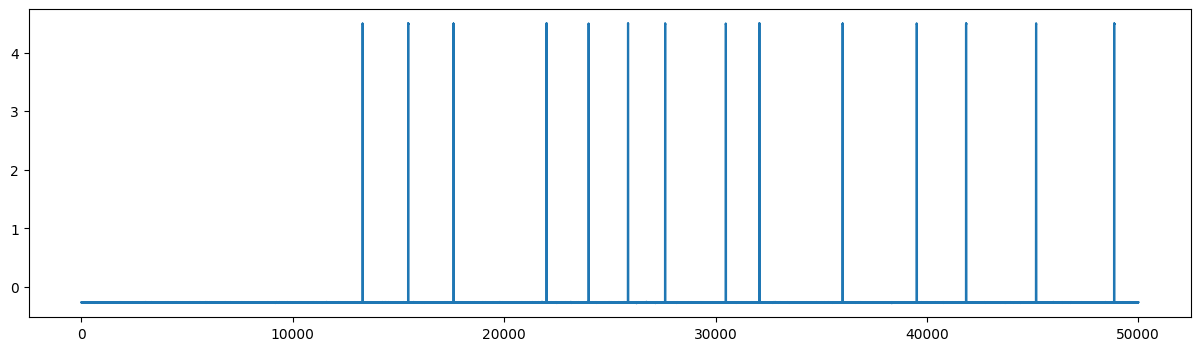

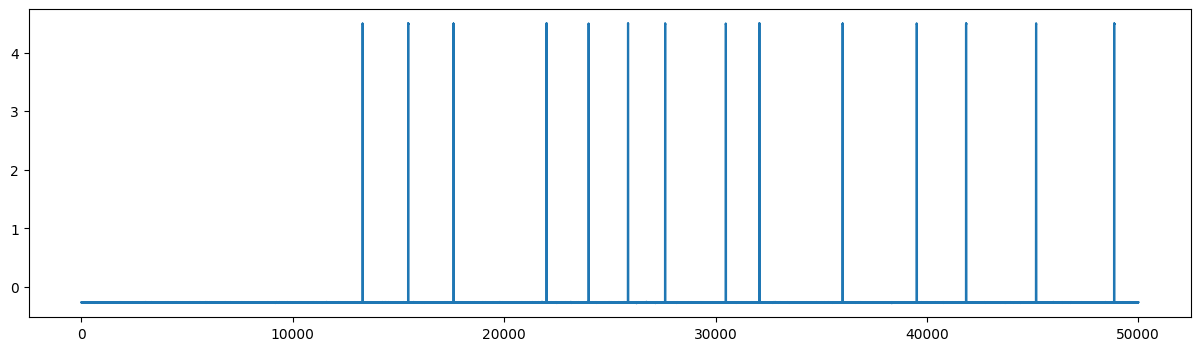

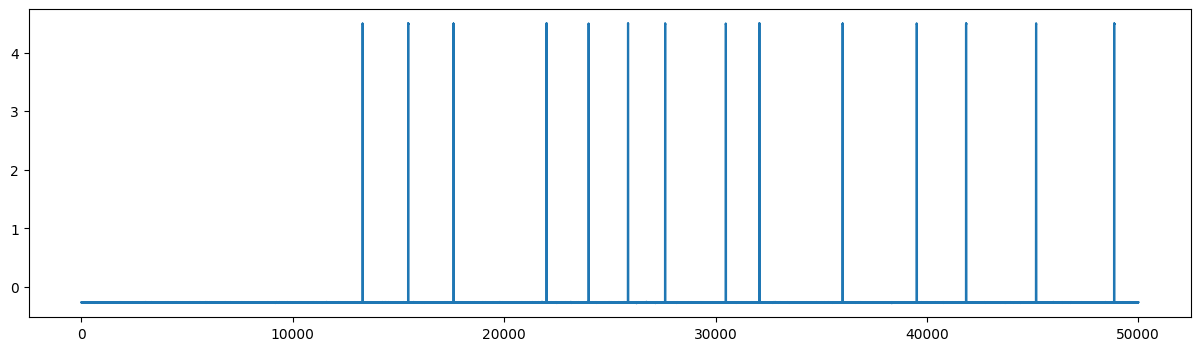

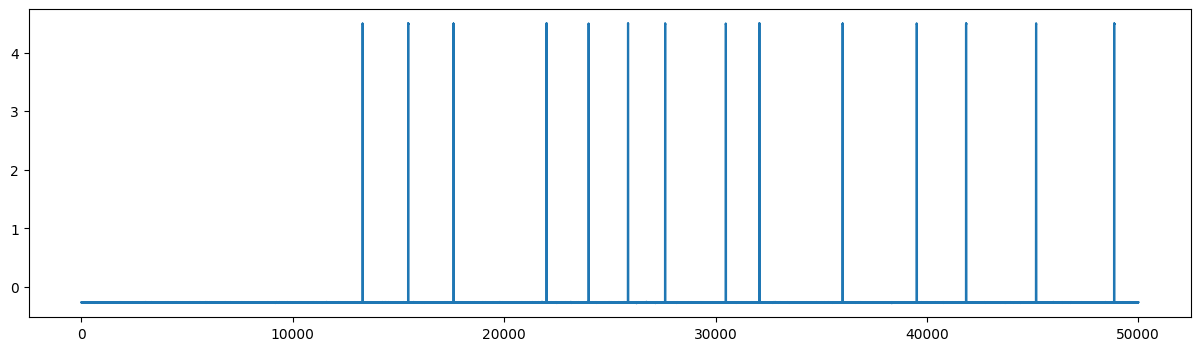

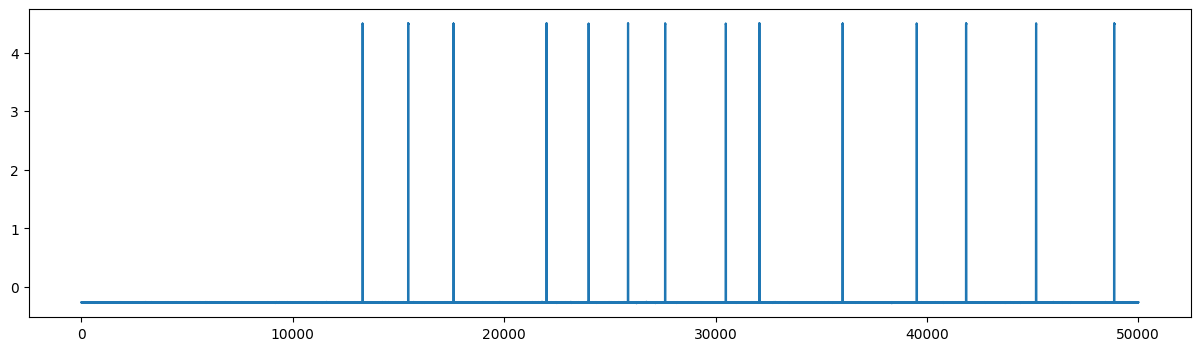

In [10]:
for file in files:
    plt.figure(figsize=(15,4))
    plt.plot(trigger[:50000])
    plt.show()

Each pulse corresponds to one auditory stimulus.

In [12]:
for file in files:
    task = file.parent.name.lower()

    if task == "motor":
        threshold = 0.5

    else:
        threshold = 2.0


    binary = trigger > threshold

    onsets = np.where(
        np.diff(binary.astype(int)) == 1
    )[0]

    print(
        "Number of events:",
        len(onsets)
    )

Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205
Number of events: 205


In [54]:
events = np.column_stack(
    [
        onsets,
        np.zeros(
            len(onsets),
            dtype=int
        ),
        np.ones(
            len(onsets),
            dtype=int
        )
    ]
)

print(events.shape)

(200, 3)


Created a matrix of shape (200,3) where each row contains sample index, previous event value, event identifier.

### 5. Epoching: 
   
one trial = brain response around one stimulus

For:
- Auditory: typically -200 ms to +500 ms

Continuous recordings are next divided into individual trials. Each epoch represents one brain response surrounding one auditory stimulus.

In [55]:
epochs = mne.Epochs(
    raw_filt,
    events,
    event_id=1,
    tmin=-0.2,
    tmax=0.5,
    baseline=(-0.2, 0),
    preload=True
)

print(epochs)

Not setting metadata
200 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 200 events and 1401 original time points ...
0 bad epochs dropped
<Epochs | 200 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~64.2 MiB, data loaded,
 '1': 200>


### 6. Tensor Shape

The epochs are converted into a NumPy array.

In [56]:
X = epochs.get_data()

print(X.shape) # (n_epochs, n_channels, n_times)

(200, 30, 1401)


200 auditory trials

30 OPM sensors

1401 time samples

This three-dimensional tensor is the primary input for subsequent tensor decomposition methods such as Tucker, CP, Tensor Train (TT).

At this point the preprocessing pipeline has transformed the continuous recording into a structured tensor representation.

Xˉ = 1 / N​ (i = 1 -> N) ∑  ​X_i

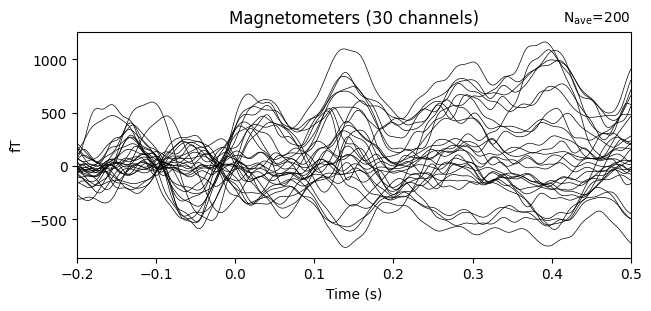

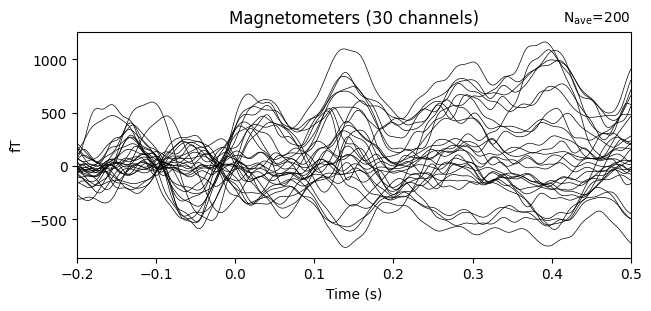

In [57]:
evoked = epochs.average()

evoked.plot()

Baseline period (-0.2 to 0 s) is relatively centered around zero.

After stimulus onset there are coherent deflections across many sensors.
Large peaks appear around:
~150 ms
~300 ms
~400 ms

Different sensors have opposite polarities, which is normal for MEG because magnetic field lines enter and leave the head.

! sound was delayed 60 ms after the onset of the auditory task

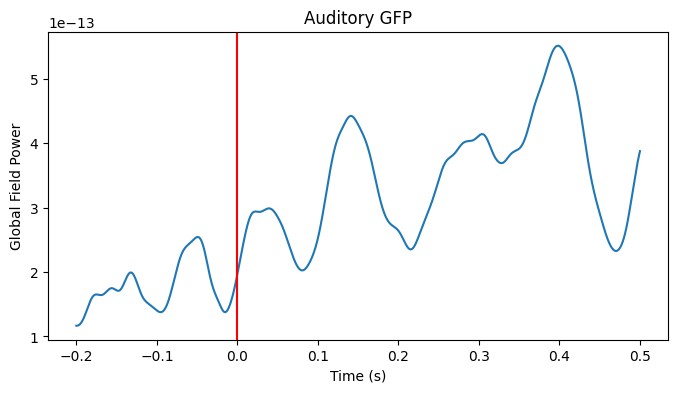

In [58]:
gfp = np.std(
    evoked.data,
    axis=0
)

plt.figure(figsize=(8,4))

plt.plot(
    evoked.times,
    gfp
)

plt.axvline(
    0,
    color="red"
)

plt.xlabel("Time (s)")
plt.ylabel("Global Field Power")

plt.title("Auditory GFP")

plt.show()

X ∈ R^ N_trial × N_channel × N_time

so

X ∈ R^ 200 × 30 × 1401

### 8. Save Tensors

In [63]:
SAVE_PATH = Path(
    "../data/preprocessed/002/auditory/run01_epochs.npz"
)

SAVE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

np.savez_compressed(
    SAVE_PATH,
    epochs=X,
    times=epochs.times,
    fs=fs,
    positions=positions,
    orientations=orientations,
    channel_names=np.array(
        channel_names,
        dtype=object
    )
)

In [64]:
data = np.load(
    "../data/preprocessed/002/auditory/run01_epochs.npz",
    allow_pickle=True
)

print(data.files)
print(data["epochs"].shape)

['epochs', 'times', 'fs', 'positions', 'orientations', 'channel_names']
(200, 30, 1401)
